## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

### Read Dataset

In [3]:
df=pd.read_csv(r"C:\Users\NAMRATA\OneDrive\Desktop\python projects\Project4_NHIS\Processed_Flipdata - Processed_Flipdata.csv")

### Analyze Top Rows

In [4]:
df.head()

,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
1,1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
2,2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,"11,999"
3,3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,"5,649"
4,4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,"8,999"


### Analyze Bottom Rows to verify if the data is fully loaded or not

In [5]:
df.tail()

,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
536,637,SAMSUNG Galaxy S23 5G,Cream,256,8,3900,50MP,12MP,0,15.49,Qualcomm Snapdragon 8 Gen 2,"79,999"
537,638,LAVA Z21,Cyan,32,2,3100,5MP,2MP,0,12.70,Octa Core,"5,998"
538,639,Tecno Spark 8T,Turquoise Cyan,64,4,5000,50MP,8MP,0,16.76,MediaTek Helio G35,"9,990"
539,641,SAMSUNG Galaxy A54 5G,Awesome Lime,128,8,5000,50MP,32MP,0,16.26,"Exynos 1380, Octa Core","38,999"
540,642,OPPO A77,Sky Blue,128,4,5000,50MP,8MP,0,16.66,Mediatek Helio G35,"15,999"


### Understand the Shape of the dataset

In [6]:
df.shape

(541, 12)

#### There are **541 rows** and **12 columns** in the dataset

### Duplicate values analyzing

In [7]:
df.duplicated().sum()

np.int64(0)

#### **No Duplicate** values found

### Checking for any missing values and Datatype of the columns before Analysis

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     541 non-null    int64  
 1   Model          541 non-null    str    
 2   Colour         541 non-null    str    
 3   Memory         541 non-null    int64  
 4   RAM            541 non-null    int64  
 5   Battery_       541 non-null    int64  
 6   Rear Camera    541 non-null    str    
 7   Front Camera   541 non-null    str    
 8   AI Lens        541 non-null    int64  
 9   Mobile Height  541 non-null    float64
 10  Processor_     541 non-null    str    
 11  Prize          541 non-null    str    
dtypes: float64(1), int64(5), str(6)
memory usage: 50.8 KB


## Data Cleaning and Transformation

#### Data cleaning steps included removing the unnecessary Unnamed column for better data quality.converting the Prize column to integer format, transforming the AI Lens column from binary (0/1) to Boolean. 

#### Drop Unnamed Column

In [9]:
df.drop(columns=['Unnamed: 0'],inplace=True)

#### Change Datatype for Prize column, since pandas read **,** as string; first remove comma and then change datatype to int.

In [10]:
df['Prize']=df['Prize'].str.replace(',','').astype(int)

#### Check value_counts for Rear Camera and Front Camera

In [11]:
df['Rear Camera'].value_counts()

Rear Camera
50MP     260
13MP      63
64MP      62
8MP       52
48MP      31
108MP     31
0MP       10
12MP      10
200MP      8
2MP        6
5MP        3
40MP       2
32MP       2
16MP       1
Name: count, dtype: int64

In [12]:
df['Front Camera'].value_counts()

Front Camera
16MP    164
5MP     135
8MP     129
13MP     49
32MP     22
0MP      16
50MP      7
12MP      6
60MP      4
2MP       3
10MP      2
20MP      2
44MP      2
Name: count, dtype: int64

#### All values in the Rear Camera and Front Camera columns contain the suffix **"MP"**. Instead of keeping them as text, the "MP" part is removed to extract only the numeric values. After that, both columns are **converted into integer data type**. This makes the dataset more consistent and allows easier analysis such as comparisons, calculations, and aggregations.

In [13]:
df['Rear Camera']=df['Rear Camera'].str.replace('MP','').astype(int)
df['Front Camera']=df['Front Camera'].str.replace('MP','').astype(int)

#### Make sure all data cleaning steps were executed successfully, and the dataset has been updated to reflect these changes, ensuring it is clean, consistent, and ready for further analysis.

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Model          541 non-null    str    
 1   Colour         541 non-null    str    
 2   Memory         541 non-null    int64  
 3   RAM            541 non-null    int64  
 4   Battery_       541 non-null    int64  
 5   Rear Camera    541 non-null    int64  
 6   Front Camera   541 non-null    int64  
 7   AI Lens        541 non-null    int64  
 8   Mobile Height  541 non-null    float64
 9   Processor_     541 non-null    str    
 10  Prize          541 non-null    int64  
dtypes: float64(1), int64(7), str(3)
memory usage: 46.6 KB


## Univariate Analysis

### Categorical Columns

### 1. Model

In [15]:
df["Model"].unique()

<StringArray>
[      'Infinix SMART 7',          'MOTOROLA G32',              'POCO C50',
       'Infinix HOT 30i',              'REDMI 10',    'SAMSUNG Galaxy F13',
    'SAMSUNG Galaxy F04',              'POCO C51',          'MOTOROLA e13',
           'vivo T2x 5G',
 ...
    'SAMSUNG Galaxy A04',         'OPPO F21s Pro',       'APPLE iPhone 12',
    'SAMSUNG Galaxy A13',        'Nokia G11 Plus',   'SAMSUNG Galaxy A04e',
 'SAMSUNG Galaxy S23 5G',              'LAVA Z21',        'Tecno Spark 8T',
              'OPPO A77']
Length: 187, dtype: str

The dataset contains a total of 187 unique phone models, making it extensive and somewhat complex to analyze in its raw form. To enhance clarity and streamline the evaluation process, the brand name and model name separates into two distinct columns. This separation allows for easier grouping of devices by brand, facilitates statistical reporting, and supports more accurate detection of inconsistencies or outliers.

In [16]:
df["Brand"]=df["Model"].str.split().str[0].str.upper()
df["Model_Name"]=df["Model"].str.split(" ",n=1).str[1]

### Drop Model column and add  Brand  and  Model_Name  column inplace 

In [17]:
df.drop(columns=["Model"], inplace=True)

In [18]:
df=df[["Brand","Model_Name"] + [col for col in df.columns if col not in["Brand","Model_Name"]]]

### The Model column was split into Brand and Model_Name, and these columns were moved to the front of the dataset to enhance clarity and support efficient data analysis.

### Univariate Analysis on Brand

In [19]:
df["Brand"].unique()

array(['INFINIX', 'MOTOROLA', 'POCO', 'REDMI', 'SAMSUNG', 'VIVO',
       'REALME', 'MICROMAX', 'GOOGLE', 'MICROMAX1', 'OPPO', 'TECNO',
       'NOTHING', 'I', 'ITEL', 'ONEPLUS', 'IQOO', 'NOKIA', 'APPLE',
       'LAVA'], dtype=object)

The extracted brand column contains inconsistencies such as typos (e.g., MICROMAX1) and incorrect splits (e.g., 'I'), indicating data quality issues during string parsing. These inaccuracies can lead to misleading analysis if not addressed. Therefore, the data should be cleaned before performing any analysis. First Check the value counts for each brand 

In [20]:
df["Brand"].value_counts()

Brand
REALME       98
REDMI        75
INFINIX      65
VIVO         62
POCO         60
SAMSUNG      55
MOTOROLA     46
TECNO        17
OPPO         16
MICROMAX     13
GOOGLE        9
ONEPLUS       5
APPLE         5
ITEL          3
NOKIA         3
NOTHING       2
I             2
IQOO          2
LAVA          2
MICROMAX1     1
Name: count, dtype: int64

In [21]:
df_filtered=df[df["Brand"].isin(["NOTHING","I","IQOO","ITEL"])]
print(df_filtered)

       Brand              Model_Name         Colour  Memory  RAM  Battery_  \
328  NOTHING                 phone 1          White     128    8      4500   
330        I  Kall Z19Pro Flash blue     Flash Blue      64    4      5000   
338        I             Kall Z19Pro           Blue      64    4      5000   
342  NOTHING                 phone 1          Black     128    8      4500   
362     ITEL                     A60     VertMenthe      32    2      5000   
367     ITEL                     A60  SapphireBlack      32    2      5000   
368     ITEL                     A60       DawnBlue      32    2      5000   
404     IQOO                Neo 7 5G     Frost Blue     128    8      5000   
522     IQOO                Neo 7 5G     Frost Blue     256    4      5000   

     Rear Camera  Front Camera  AI Lens  Mobile Height  \
328           50            16        0          16.64   
330           13             8        0          16.51   
338           13             8        0      

The dataset contains several data quality issues identified during preprocessing. The brand value “I” was found to represent the “i Kall” brand and was corrected accordingly, while “MICROMAX1” was identified as a typographical error and standardized to “MICROMAX.” Additionally, certain rows (e.g., around index 330) had color information mistakenly included within the Model column, leading to inconsistent formatting. This was resolved by removing color-related text from the model names to ensure uniformity and improve the accuracy of further analysis.

In [22]:
df["Brand"]=df["Brand"].replace({
    "MICROMAX1":"MICROMAX",
    "I":"I KALL"
})

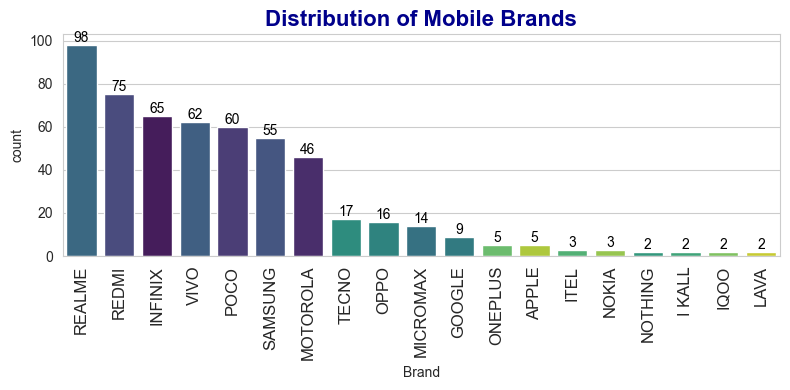

In [85]:
sns.set_style("whitegrid")
plt.figure(figsize=(8,4))

ax= sns.countplot(x=df["Brand"],hue=df["Brand"],order=df["Brand"].value_counts().index, palette="viridis",legend=False)

ax.set_title("Distribution of Mobile Brands", fontsize=16, color="darkblue", fontweight="bold")
ax.tick_params(axis='x', rotation=90, labelsize=12)

for container in ax.containers:
    ax.bar_label(container, label_type='edge', fontsize=10, color='black')

plt.tight_layout()
plt.show()

### The count plot reveals that the dataset is dominated by a few key brands such as REALME and REDMI, indicating a high concentration of models from these manufactures. Mid-range brand like INFINIX, VIVO, and POCCO also show significant representation, suggesting strong competition in these segment. Additionally, premium brands such as APPLE, ONEPLUS have limited presence, while brands like NOTHING, I KALL, IQOO, LAVA, ITEL, NOKIA have negligible representation, indicating uneven brand distribution. 

### Univariate Analysis Of Model_Name

In [24]:
df["Model_Name"]=(
    df["Model_Name"]
    .str.replace("Kall",'',case=False)
    .str.replace("Flash blue",'',case=False)
    .str.replace(r'\s+',' ',regex=True)
    .str.strip()
)

#### The term KALL was removed from the Model_Name column as it has already been captured in the Brand column.Additionally, Flas blue being a color attribute, was also removed. All extra spaces, including trailing, leading and multiple intwermediate spaces, were handled to ensure clean and consistene formatting.

In [25]:
df[df["Model_Name"].isna()]

,Brand,Model_Name,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
116,MICROMAX,NaN,OMG Black,128,4,1000,0,0,0,4.5,SC6531E,1422
181,MICROMAX,NaN,Light Silver,32,3,2550,0,0,0,4.5,SC6531E,1375
182,MICROMAX,NaN,Light Silver,32,3,800,0,0,0,4.5,SC6531E,1599
250,MICROMAX,NaN,Lake Blue,64,4,1500,0,0,0,6.1,Mediatek MT6261D,1199


In [26]:
df["Model_Name"]=df["Model_Name"].fillna("Unknown")

#### After seperating the Model column into individual features, the dataset was checked for missing values in the Model_Name column, and any null values are replaced with "Unknown" to ensure data completeness. 

In [27]:
df["Model_Name"]=df["Model_Name"].str.lower().str.title()

In [28]:
df["Model_Name"].unique()

array(['Smart 7', 'G32', 'C50', 'Hot 30I', '10', 'Galaxy F13',
       'Galaxy F04', 'C51', 'E13', 'T2X 5G', 'Smart 7 Hd', 'A1+', 'C55',
       'G13', 'M4 5G', 'E32', 'T2 5G', 'G62 5G', 'M5', 'C33 2023',
       'Galaxy F14 5G', 'G73 5G', 'C30', 'X5 5G', 'M4 Pro', '11 Prime',
       '10 Pro 5G', 'In 2C', 'M4 Pro 5G', 'Narzo 30 Pro 5G', '2',
       'Note 12 Pro 5G', 'Galaxy F23 5G', 'Unknown', 'Edge 40', '1',
       'Narzo 30', 'Note 12I', '8I', '3', 'Pixel 6A', 'Hot 20 5G', 'Gt 2',
       'Note 12', 'Note 12 5G', 'Galaxy M04', 'K50I 5G', 'E40', '9 Activ',
       'G42', 'C25S', 'X5 Pro 5G', 'M3 Pro 5G', 'Smart 6 Hd', 'C31',
       'A17', '9 5G Se', '9I 5G', 'C21Y', 'Narzo 50I Prime',
       'Zero 5G 2023', 'X4 Pro 5G', 'G82 5G', 'Note 12 Pro+ 5G', 'T1 44W',
       'G31', 'Galaxy S22 Plus 5G', 'V27 5G', 'Narzo 50', 'Hot 20 Play',
       'G52', 'A17K', 'F5 5G', 'Max', 'Mono', 'Min', '9 Pro+ 5G',
       'Hot 12', 'G72', 'Y16', 'Narzo 50I', 'Galaxy Z Flip3 5G', 'C33',
       'Zero 20', '8', '

In [29]:
df["Model_Name"].nunique()

171

### Distribution of Model_Name

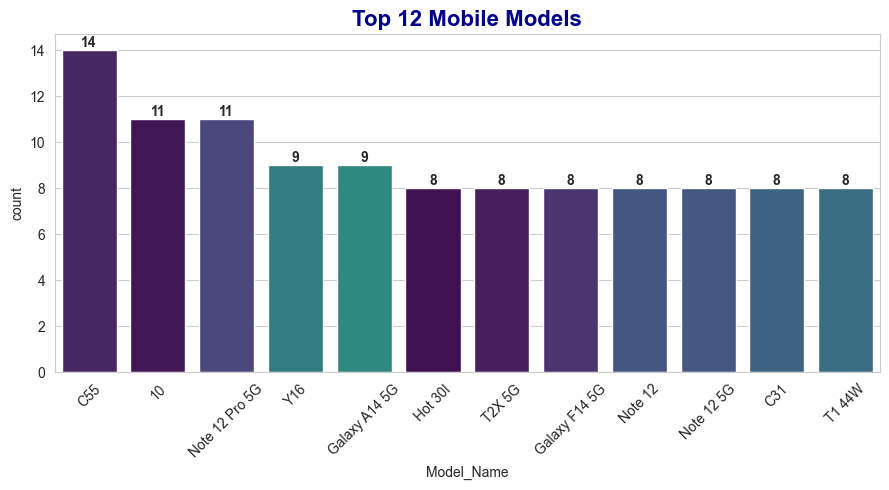

### Model with 7 entries: 0 models
**Examples:** []

### Model with 6 entries: 13 models
**Examples:** ['Galaxy F13', 'A1+', 'M5', 'C33 2023', '11 Prime', '10 Pro 5G', 'Galaxy F23 5G', 'K50I 5G', 'X5 Pro 5G', '9I 5G', 'Note 12 Pro+ 5G', 'F5 5G', '10 Pro+ 5G']

### Model with 5 entries: 11 models
**Examples:** ['C50', 'E13', 'M4 5G', 'X5 5G', 'Hot 20 5G', 'X4 Pro 5G', 'C33', 'Spark 9T', 'Spark Go 2023', 'Galaxy A34 5G', 'Hot 12 Pro']

### Model with 4 entries: 20 models
**Examples:** ['G32', 'Smart 7 Hd', 'T2 5G', 'G62 5G', 'C30', 'M4 Pro', 'M4 Pro 5G', 'Unknown', 'G42', 'A17', 'Narzo 50I Prime', 'Hot 20 Play', 'A17K', 'Hot 12', '8', 'Smart 6', 'C30S', 'Y56 5G', 'Y100 5G', 'T1 Pro 5G']

### Model with 3 entries: 33 models
**Examples:** ['Smart 7', 'G13', 'E32', 'In 2C', '2', 'Edge 40', 'Narzo 30', 'Note 12I', '3', 'Pixel 6A', 'Gt 2', 'Smart 6 Hd', 'Zero 5G 2023', 'V27 5G', 'Narzo 50', 'G52', '9 Pro+ 5G', 'Narzo 50I', 'Pixel 7A', 'Spark 9', 'Zero 5G 2023 Turbo', 'Galaxy A23 5G', 'A60', 'V23 5G', '9I', 'Narzo 50A Prime', 'Pixel 7', 'Galaxy A23', 'V25 5G', 'Note 11T 5G', 'Galaxy A54 5G', 'Iphone 14 Plus', 'V25 Pro 5G']

### Model with 2 entries: 37 models
**Examples:** ['Galaxy F04', 'C51', 'G73 5G', '8I', 'Galaxy M04', '9 Activ', 'C25S', '9 5G Se', 'G82 5G', 'G31', 'Max', 'Min', 'G72', 'Zero 20', 'Y35', 'Edge 30', 'Edge 30 Fusion', 'Reno8T 5G', 'Phone 1', 'Z19Pro', 'C35', 'Nord 2T 5G', 'Narzo N55', 'Pop 5 Pro', 'A77S', 'Edge 30 Ultra', 'Neo 7 5G', 'Hot 12 Play', 'Y75', 'Narzo 50A', '9A Sport', 'X3 Superzoom', 'C01 Plus', '10A Sport', 'Hot 11', 'Note 12 Pro', '9 5G']

### Model with 1 entries: 45 models
**Examples:** ['Narzo 30 Pro 5G', '1', 'E40', 'M3 Pro 5G', 'C21Y', 'Galaxy S22 Plus 5G', 'Mono', 'Galaxy Z Flip3 5G', 'X2', 'A78 5G', '10 Prime 2022', 'G22', 'F1', 'Y12G', 'Note 11', 'Galaxy S21 Fe 5G', 'F21 Pro', 'Note 11S', 'Y1S', 'Nord', 'Y33S', 'Note 10S', 'Iphone 11', 'Smart 5A', 'E22S', 'Note 9', 'Y565G', 'M53 5G', 'Note 10 Lite', 'Pova 3', '12C', 'Z2', 'Note 11S Free Fire Edition', 'C11 2021', 'Y21T', 'Galaxy A04', 'F21S Pro', 'Iphone 12', 'Galaxy A13', 'G11 Plus', 'Galaxy A04E', 'Galaxy S23 5G', 'Z21', 'Spark 8T', 'A77']

In [30]:
display(Markdown("### Distribution of Model_Name"))
sns.set_style("whitegrid")

plt.figure(figsize=(9,5))

top12_models=df["Model_Name"].value_counts().head(12).index

ax=sns.countplot(x=df["Model_Name"],order=top12_models, hue=df["Model_Name"],palette="viridis")
ax.set_title("Top 12 Mobile Models", fontsize=16, color="darkblue", fontweight="bold")
ax.tick_params(axis='x', rotation=45)

for container in ax.containers:
    ax.bar_label(container, label_type='edge', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

model_count=df["Model_Name"].value_counts()

for i in range(7,0,-1):
    models=model_count[model_count==i].index.tolist()
    display(Markdown(
        f"### Model with {i} entries: {len(models)} models\n"
        f"**Examples:** {models}"
    ))

### Distribution of Model_Name

Few model dominates the dataset like C55,10 and Note 12 Pro 5G contribute a large share of total records. Most model have relatively low representation. Models like Y16, Galaxy A14 5G, Hot 30i, T2x,Note 12 , etc,... falls in Moderate Frequency. No model appears exactly 7 times. Large propotion appears only once , twice or thrice.

In [31]:
df['Model_Name'] = df['Model_Name'].str.lower().str.strip()
def group_model(name):
    if 'galaxy' in name:
        return 'Samsung Galaxy'
    elif 'note' in name:
        return 'Note Series'
    elif 'narzo' in name:
        return 'Narzo Series'
    elif 'iphone' in name:
        return 'iPhone'
    elif 'pixel' in name:
        return 'Pixel'
    elif 'hot' in name:
        return 'Hot Series'
    elif 'spark' in name:
        return 'Spark Series'
    elif 'smart' in name:
        return 'Smart Series'
    else:
        return 'Other'
    
df['Model_Group'] = df['Model_Name'].apply(group_model)
df['Model_Group'].value_counts()

Model_Group
Other             346
Samsung Galaxy     54
Note Series        47
Hot Series         30
Narzo Series       21
Smart Series       15
Spark Series       14
Pixel               9
iPhone              5
Name: count, dtype: int64

#### Samsung Galaxy has 54 entries, making it most prominant identified group, Note Series account for 47 entries; this suggest that Note and Galaxy  Models are highly common, ppossibly due to multiple variants.

#### Hot Series, Nazaro series, Smart Series, and Spark Series represent mid-range.

#### Premium smartphone segments like Pixel and iPhone are underrepresented, suggesting limited coverage of high end device

#### The distribution of Model_Group shows a strong skew towards other category.

## 2. Colour

In [32]:
df['Colour'] = df['Colour'].str.title()

In [33]:
df["Colour"].describe()

count        541
unique       271
top       Yellow
freq          12
Name: Colour, dtype: object

In [34]:
df["Colour"].unique()

<StringArray>
[     'Night Black',       'Azure Blue',     'Mineral Gray',
       'Royal Blue',         'Marigold',     'Glacier Blue',
     'Mirror Black',    'Diamond White',     'Shadow Black',
    'Emerald Green',
 ...
 'Supersonic Black',        'Starlight',      'Metal Black',
    'Twilight Gold',           'Copper',  'Starlight Black',
            'Cream',             'Cyan',     'Awesome Lime',
         'Sky Blue']
Length: 271, dtype: str

#### The dataset contains 271 unique values in the color column, with yellow appearing most frequently(12 occurences). However several entries reprents variation of same base colour-for exampleAzure blue and Royal blue can all be grouped under Blue, while similar cases exists for Black. To address this new standarized column should be created that consolidates such variation into broader colour categories, ensuring consistency and reducing redundancy in the dataset.

In [35]:
def normalize_color(col):
    original=col
    col=str(col).lower()

    if "blue" in col or "sky" in col or "aqua" in col or "azure" in col or "sea" in col or "ocean" in col or "wave" in col:
        return "Blue"
    elif"black" in col or "matter" in col or "charcoal" in col or "obsidian" in col or "night" in col or "moonlight" in col or "m3)" in col:
        return "Black"
    elif "red" in col:
        return "Red"
    elif "grey" in col or "gray" in col or "graphite" in col:
        return "Grey"
    elif "white" in col or "snow" in col or "ice" in col:
        return "White"
    elif "green" in col or "lime" in col or "lemon" in col or "rainfo" in col or "vertmenthe" in col:
        return "Green"
    elif "purple" in col or "violet" in col:
        return "Purple"
    elif "orange" in col:
        return "Orange"
    elif "gold" in col:
        return "Gold"
    elif "silver" in col:
        return "Silver"
    elif "cyan" in col:
        return "Cyan"
    elif "copper" in col or "bronze" in col or "brown" in col:
        return "Brown"
    elif "yellow" in col:
        return "Yellow"
    else:
        return original
    
df["Base_Colour"]=df["Colour"].apply(normalize_color)

### Base Colour Distribution

Base_Colour
Black                162
Blue                 153
Green                 57
White                 33
Grey                  21
Gold                  21
Purple                19
Silver                15
Yellow                12
Orange                10
Cyan                   7
Brown                  6
Red                    5
Hyperspace             4
Sunshower              3
Nitro Blaze            2
Chalk                  2
Metallic Rose          2
Peach                  2
Starry Glow            1
Jade Fog               1
Interstellar Glow      1
Starlight              1
Cream                  1
Name: count, dtype: int64

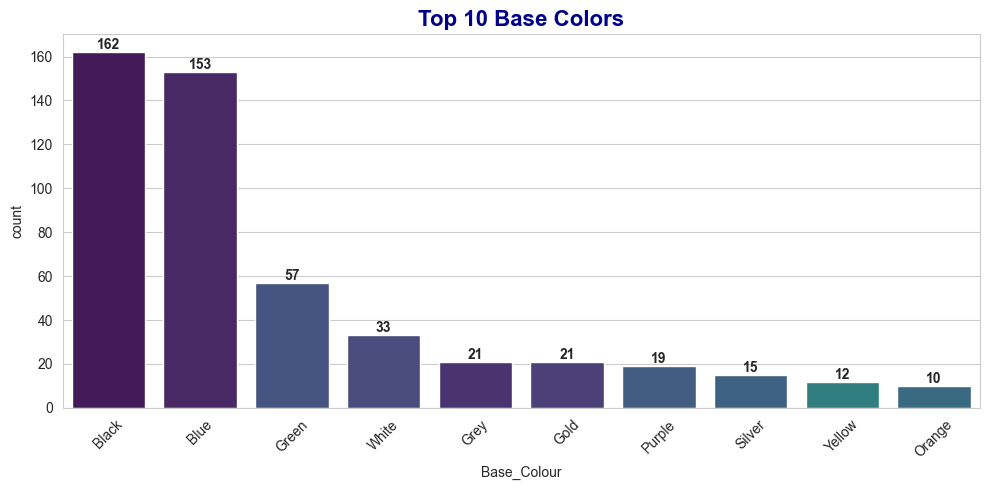

In [36]:
display(Markdown("### Base Colour Distribution"))
                 
display(df["Base_Colour"].value_counts())

sns.set_style("whitegrid")

plt.figure(figsize=(10,5))

top10_color=df["Base_Colour"].value_counts().head(10).index

ax=sns.countplot(x=df["Base_Colour"], hue=df["Base_Colour"], order=top10_color,palette="viridis")
ax.set_title("Top 10 Base Colors", fontsize=16, color="darkblue", fontweight="bold")
ax.tick_params(axis='x', rotation=45)

for container in ax.containers:
    ax.bar_label(container, label_type='edge', fontsize=10, fontweight='bold') 

plt.tight_layout()
plt.show()


### Distribution of Colour
#### Neutral and widely preferred colors such as Black (162) and Blue (153) dominate the dataset, indicating a strong consumer inclination toward classic and versatile shades. 

#### There is a noticeable decline in frequency after these leading colors, with Green (57) and White (33) representing the next tier of preference. 

#### Colors such as Grey (21), Gold (21), Purple (19), and Silver (15) offer moderate variety but do not compete with the top categories in terms of popularity. 

#### Brighter and more vibrant colors, including Yellow (12), Orange (10), Cyan (7), and Red (5), show relatively lower adoption, suggesting limited consumer preference for bold color options. 

#### Additionally, entries such as Hyperspace (4), Sunshower (3), Nitro Blaze (2), and Starry Glow (1) represent marketing-driven color names rather than standardized color categories, indicating a need for further normalization in the dataset.

## 3.Processor

In [37]:
df["Processor_"]=df["Processor_"].str.title()

In [38]:
df["Processor_"].nunique()

113

In [39]:
df["Processor_"].unique()

<StringArray>
[              'Unisoc Spreadtrum Sc9863A1',
                  'Qualcomm Snapdragon 680',
                       'Mediatek Helio A22',
                                      'G37',
                               'Exynos 850',
                       'Mediatek Helio P35',
                                'Helio G36',
                              'Unisoc T606',
                           'Dimensity 6020',
                      'Spreadtrum Sc9863A1',
 ...
                        'Mtk Dimensity 700',
                 'Qualcomm Snapdragon 720G',
                  'Mediatek Dimensity 1300',
                       'Mediatek Helio G70',
                                'Octa-Core',
                                   '6 Core',
                           'Dimensity 8200',
 'Qualcomm Sm6225 Snapdragon 680 4G (6 Nm)',
                         'Exynos Octa Core',
              'Qualcomm Snapdragon 8 Gen 2']
Length: 113, dtype: str

### The processor column contains 113 unique values and requires cleaning. Some values include brand names, while others refer to company names, so normalization should be performed first. Additionally, several entries specify core configurations such as "6 Core" and "Octa Core," which also need to be handled appropriately during preprocessing.

In [40]:
# 1. Remove duplicate prefixes
df['Processor_'] = df['Processor_'].str.replace(
    r'(?i)\b(unisoc|qualcomm)\s+\1\b', r'\1', regex=True
)

# 2. Fix SC9863A / SC9863A1 variations
df['Processor_'] = df['Processor_'].str.replace(
    r'(?i)sc9863a/?\s*sc9863a1',
    'Unisoc SC9863A1',
    regex=True
)

df['Processor_'] = df['Processor_'].str.replace(
    r'(?i)\bsc9863a\b',
    'Unisoc SC9863A',
    regex=True
)

# 3. Clean "Unisoc Tiger"
df['Processor_'] = df['Processor_'].str.replace(
    r'(?i)unisoc tiger', 'Unisoc', regex=True
)

# 4. Fix Mediatek Mt chips
df['Processor_'] = df['Processor_'].str.replace(
    r'(?i)mediatek\s*mt(\d+)', r'Mediatek \1', regex=True
)

# 5. Fix standalone Mt chips (Mt6260A etc.)
df['Processor_'] = df['Processor_'].str.replace(
    r'(?i)^mt(\d+)', r'Mediatek \1', regex=True
)

# 6. Fix weird Snapdragon 0084
df['Processor_'] = df['Processor_'].str.replace(
    r'(?i)snapdragon\s*0084', 'Qualcomm Snapdragon 765G', regex=True
)

# 7. Clean Exynos inside brackets
df['Processor_'] = df['Processor_'].str.replace(
    r'(?i).*exynos\s*(\d+).*', r'Exynos \1', regex=True
)

# 8. Fix Unisoc SC9863A1 variations
df['Processor_'] = df['Processor_'].str.replace(
    r'(?i)unisoc\s+unisoc\s*sc9863a/?\s*unisoc\s*sc9863a1',
    'Unisoc SC9863A1',
    regex=True
)
# 9. Final clean (run only once at the end)
df['Processor_'] = df['Processor_'].str.strip().str.title()

In [41]:
df["Processor_"].unique()

<StringArray>
[              'Unisoc Spreadtrum Sc9863A1',
                  'Qualcomm Snapdragon 680',
                       'Mediatek Helio A22',
                                      'G37',
                               'Exynos 850',
                       'Mediatek Helio P35',
                                'Helio G36',
                              'Unisoc T606',
                           'Dimensity 6020',
                      'Spreadtrum Sc9863A1',
 ...
                        'Mtk Dimensity 700',
                 'Qualcomm Snapdragon 720G',
                  'Mediatek Dimensity 1300',
                       'Mediatek Helio G70',
                                'Octa-Core',
                                   '6 Core',
                           'Dimensity 8200',
 'Qualcomm Sm6225 Snapdragon 680 4G (6 Nm)',
                         'Exynos Octa Core',
              'Qualcomm Snapdragon 8 Gen 2']
Length: 111, dtype: str

In [42]:
df['Processor_Category'] = df['Processor_'].str.extract(
    r'(Qualcomm Snapdragon|Mediatek Helio|Mediatek Dimensity|Unisoc|Exynos|Tensor|Unknown)',
    expand=False
)

df['Processor_Category'] = df['Processor_Category'].fillna('Other')

df['Processor_Category'].value_counts()

Processor_Category
Other                  129
Mediatek Helio         121
Qualcomm Snapdragon    115
Mediatek Dimensity      80
Unisoc                  58
Exynos                  30
Tensor                   8
Name: count, dtype: int64

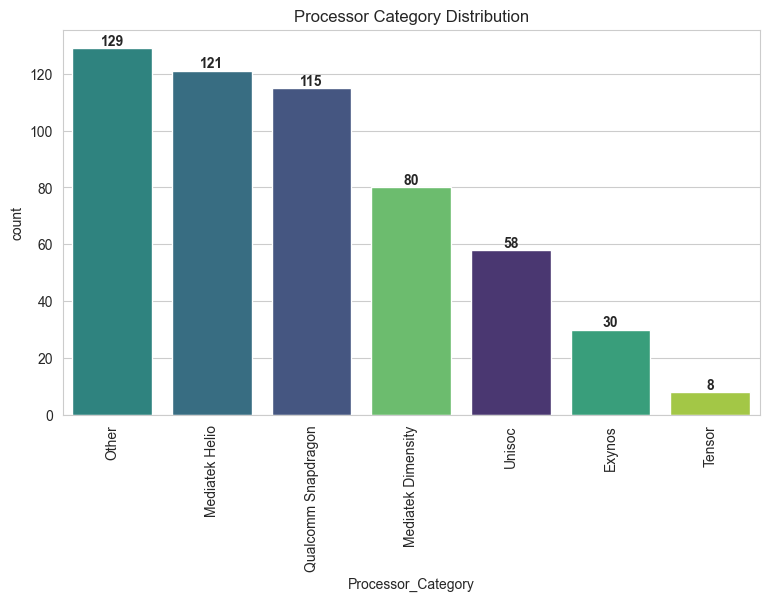

In [43]:
sns.set_style("whitegrid")
plt.figure(figsize=(9,5))

ax=sns.countplot(
    data=df, x='Processor_Category', hue='Processor_Category', palette="viridis", order=df['Processor_Category'].value_counts().index)

plt.title('Processor Category Distribution')
plt.xticks(rotation=90)
 
for container in ax.containers:
    ax.bar_label(container, label_type='edge', fontsize=10, fontweight='bold')

plt.show()

### Processor_Category Distribution

#### The processor category distribution shows a strong dominance of Mediatek and Qualcomm chipsets in the dataset. Mediatek Helio leads with 170 entries, followed by Qualcomm Snapdragon at 130 and Mediatek Dimensity at 109. This indicates that **Mediatek (Helio + Dimensity combined)** holds the largest share, highlighting its strong presence, especially in budget and mid-range devices.

#### Unisoc appears with 64 entries, suggesting a moderate presence. Exynos has 26 entries, reflecting a limited but consistent usage, mainly associated with specific brands.

#### The presence of 21 "Unknown" values indicates remaining data quality issues that may need further cleaning or validation. Additionally, 13 entries categorized as "Other" suggest rare or less common processors that were grouped due to low frequency.

#### Tensor processors appear only 8 times, showing minimal representation, likely limited to specific premium devices.

#### Overall, the distribution is highly imbalanced, with a few dominant processor categories and several low-frequency groups. This suggests that most smartphones in the dataset rely on a small set of widely adopted chipsets, while others have niche or limited usage.

### Numerical Columns

 ### 1. Memory

## Statistical Analysis-Memory

### Summary Statistics

,Value
Count,541.00
Mean,110.55
Std Dev,60.60
Min,16.00
25%,64.00
Median,128.00
75%,128.00
Max,256.00


### Distribution Shape

,Metric,Value
0,Skewness,1.03
1,Kurtosis,0.86


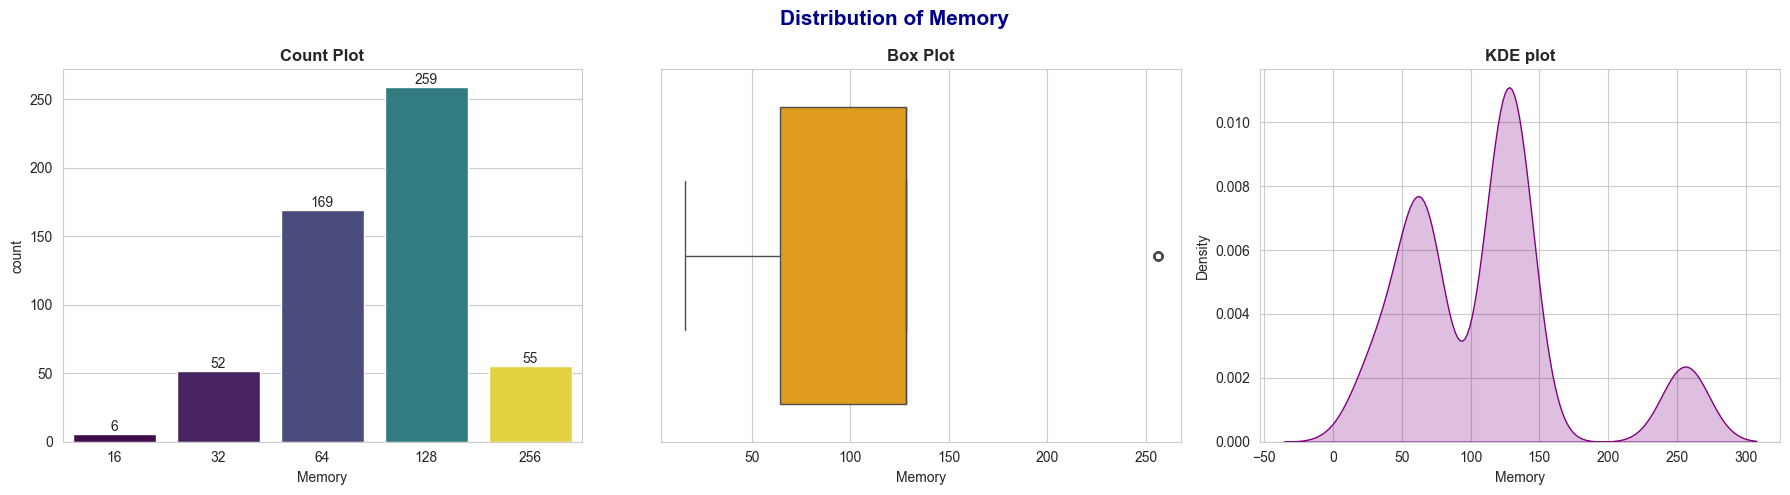

In [44]:
display(Markdown("## Statistical Analysis-Memory"))

## Summary Statistical 
display(Markdown("### Summary Statistics"))
stat=df['Memory'].describe().to_frame(name='Value').round(2)
stat.index=["Count","Mean","Std Dev","Min","25%","Median","75%","Max"]
display(stat)

## Skewness & kurtosis
display(Markdown("### Distribution Shape"))
shape_stat=pd.DataFrame({
    "Metric":["Skewness","Kurtosis"],
    "Value":[df["Memory"].skew(),df["Memory"].kurt()]
})
shape_stat["Value"]=shape_stat["Value"].round(2)
display(shape_stat)

## Visualization
sns.set_style("whitegrid")

## create subplots
fig, ax=plt.subplots(1,3, figsize=(18,5))



## count plot
sns.countplot(x=df["Memory"], ax=ax[0], hue=df["Memory"], palette="viridis", legend=False)
ax[0].set_title("Count Plot", fontsize=12, fontweight="bold")

## label
for container in ax[0].containers:
    ax[0].bar_label(container)

## box plot
sns.boxplot(x=df["Memory"], ax=ax[1], color="orange")
ax[1].set_title("Box Plot", fontsize=12, fontweight="bold")


## kde plot
sns.kdeplot(df["Memory"],fill=True, ax=ax[2], color="purple")
ax[2].set_title("KDE plot", fontsize=12, fontweight="bold")

plt.suptitle("Distribution of Memory", fontsize=15, fontweight="bold", color="darkblue")
plt.tight_layout()
plt.show()

#### Distribution and Statistical Analysis of Memory Column

The Memory column contains 541 observations with values ranging from 16 GB to 256 GB.

- The average memory is approximately 110.55 GB, while the median is 128 GB.
- Since the mean is lower than the median, the distribution is slightly left-skewed, indicating the presence of lower memory values pulling the average down.
- The interquartile range (IQR) shows that 50% of the devices have memory between 64 GB and 128 GB.
- Notably, both the median (50%) and the 75th percentile are 128 GB, suggesting a high concentration of devices at this value

---

Skewness & Shape

- Skewness = 1.03 → Positively skewed distribution
- Kurtosis = 0.86 → Slightly leptokurtic. Distribution has moderate peaks (not too flat)

---

Outliers & Boxplot
- The interquartile range (IQR) lies between 64 GB and 128 GB, indicating that the majority of devices are concentrated within this range.
- The median (128) aligns with the upper quartile (Q3), highlighting a strong clustering of observations at 128 , making it the most common configuration.
- Since 256 GB is a valid real-world value, it should be verified using value counts and checked for consistency with other attributes. Only if it appears inconsistent or rare should it be considered a potential typo and corrected accordingly.

---

Density (KDE Plot)

- The KDE curve shows multiple peaks, suggesting market is segmented (budget: 64 GB, mid-range: 128 GB, premium: 256 GB)
- The distribution shows a slight positive skew, with the upper range extending toward higher memory values while most data remains concentrated at 128 GB.
- Highest density around 128 GB, confirming it as the most popular choice.

#### Outliers in Memory coulmn

In [45]:
q1=df["Memory"].quantile(0.25)
q3=df["Memory"].quantile(0.75)

iqr=q3-q1

upper_bound=q3+1.5*iqr
lower_bound=q1-1.5*iqr

outliers=df[(df["Memory"]<lower_bound) | (df["Memory"]>upper_bound)]
print(outliers["Memory"].value_counts())

Memory
256    55
Name: count, dtype: int64


#### Although 256 GB is flagged as an outlier by the IQR method due to clustering of values around 128 GB, it is a valid storage category. Memory values are discrete and follow standard configurations rather than a continuous distribution. Since 256 GB appears 55 times, it represents a meaningful segment rather than a rare anomaly. Therefore, it should be retained as it reflects real-world high-end devices.

## 2. RAM

## Statistical Analysis-RAM

### Summary Statistics

,value
Count,541.00
Mean,5.40
Std Dev,1.98
Min,2.00
25%,4.00
Median,6.00
75%,8.00
Max,8.00


### Distribution of Shape

,Metric,Value
0,Skewness,0.07
1,Kurtosis,-1.31


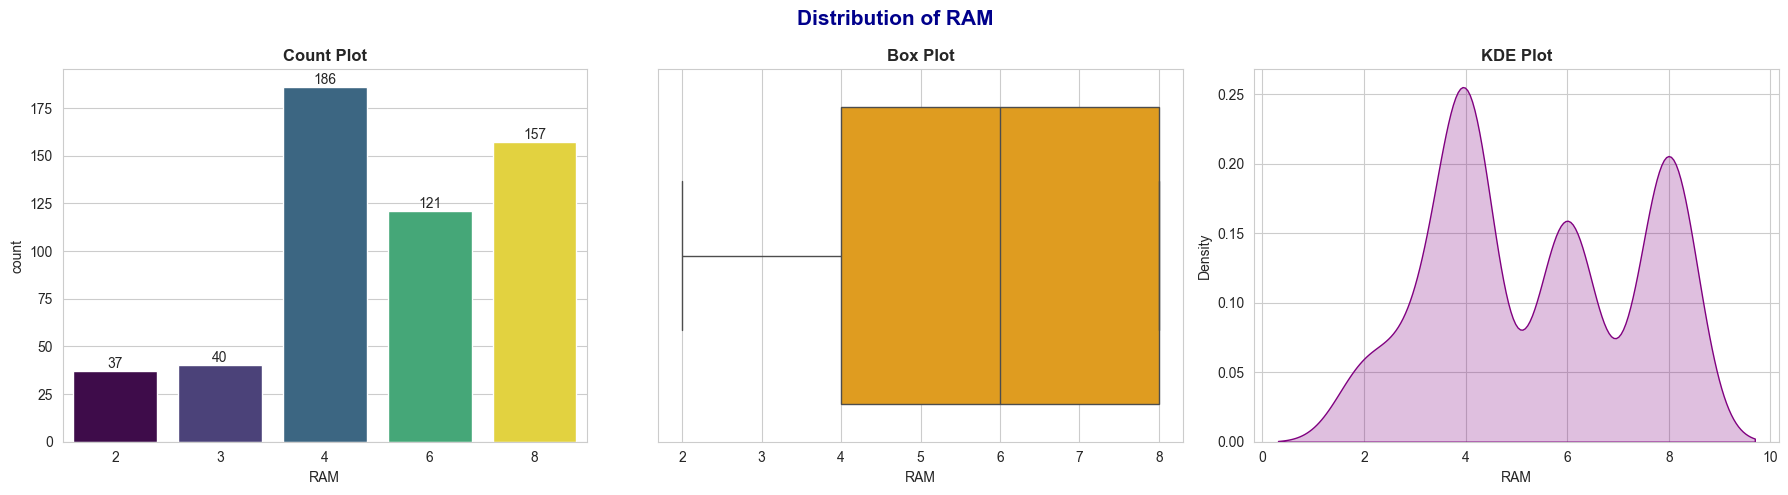

In [46]:
## Statistical distribution
display(Markdown("## Statistical Analysis-RAM"))

display(Markdown("### Summary Statistics"))
stat=df["RAM"].describe().to_frame(name="value").round(2)
stat.index=["Count","Mean","Std Dev","Min","25%","Median","75%","Max"]
display(stat)

## skewness and kurtosis
display(Markdown("### Distribution of Shape"))
shape_stat= pd.DataFrame({
    "Metric": ["Skewness","Kurtosis"],
    "Value": [df["RAM"].skew(),df["RAM"].kurt()]
})

shape_stat["Value"]=shape_stat["Value"].round(2)
display(shape_stat)

## Visualization

sns.set_style("whitegrid")

fig, ax=plt.subplots(1,3, figsize=(18,5))

## Count Plot
sns.countplot(x=df["RAM"], ax=ax[0], palette="viridis", hue=df["RAM"], legend=False)
ax[0].set_title("Count Plot", fontsize=12, fontweight="bold")

## labels
for container in ax[0].containers:
    ax[0].bar_label(container, labels=[f"{int(v)}" for v in container.datavalues])


## box plot
sns.boxplot(x=df["RAM"], ax=ax[1], color="orange")
ax[1].set_title("Box Plot", fontsize=12, fontweight="bold")

## kde plot
sns.kdeplot(x=df["RAM"], ax=ax[2], color="purple", fill=True)
ax[2].set_title("KDE Plot", fontsize=12, fontweight="bold")


plt.suptitle("Distribution of RAM", fontsize=15, fontweight="bold", color="darkblue")

plt.tight_layout()
plt.show()


### **Distribution and Statisitcal Analysis of RAM**


- The **4 GB RAM variant has the highest frequency**, followed by **8 GB and 6 GB**. This indicates strong usage of **mid-range configurations** in the dataset.
- The **mean RAM is ~5.4 GB** and the **median is 6 GB**.
- Since mean and median are very close, the distribution is **nearly symmetric**.
- RAM values range from **2 GB to 8 GB**, showing moderate variability.
- The interquartile range (**4 GB to 8 GB**) indicates that most devices fall within this band.

---

Skewness & Shape

- Skewness = 0.07 indicating Distribution is approximately symmetric
- Kurtosis = -1.31 means Platykurtic distribution,indicates a flatter distribution with less extreme peaks

---
Box Plot Insight

- No significant outliers are observed.
- The data is evenly spread, with the median positioned near the center of the box.

---

Density (KDE) Insight

- The KDE plot shows **multiple peaks**, suggesting market segmentation (budget: 2–3 GB, mid-range: 4–6 GB, higher: 8 GB)
- Highest density observed around **4 GB and 8 GB**.



## 3. Battery

## Statistical Analysis

### Summary Statics

,Value
Count,541.00
Mean,4871.59
Std Dev,780.15
Min,800.00
25%,5000.00
Median,5000.00
75%,5000.00
Max,7000.00


### Skewness and Kurtosis

,Metric,Value
0,Skewness,-3.30
1,Kurtosis,14.75


Battery Unique No. Count:  37


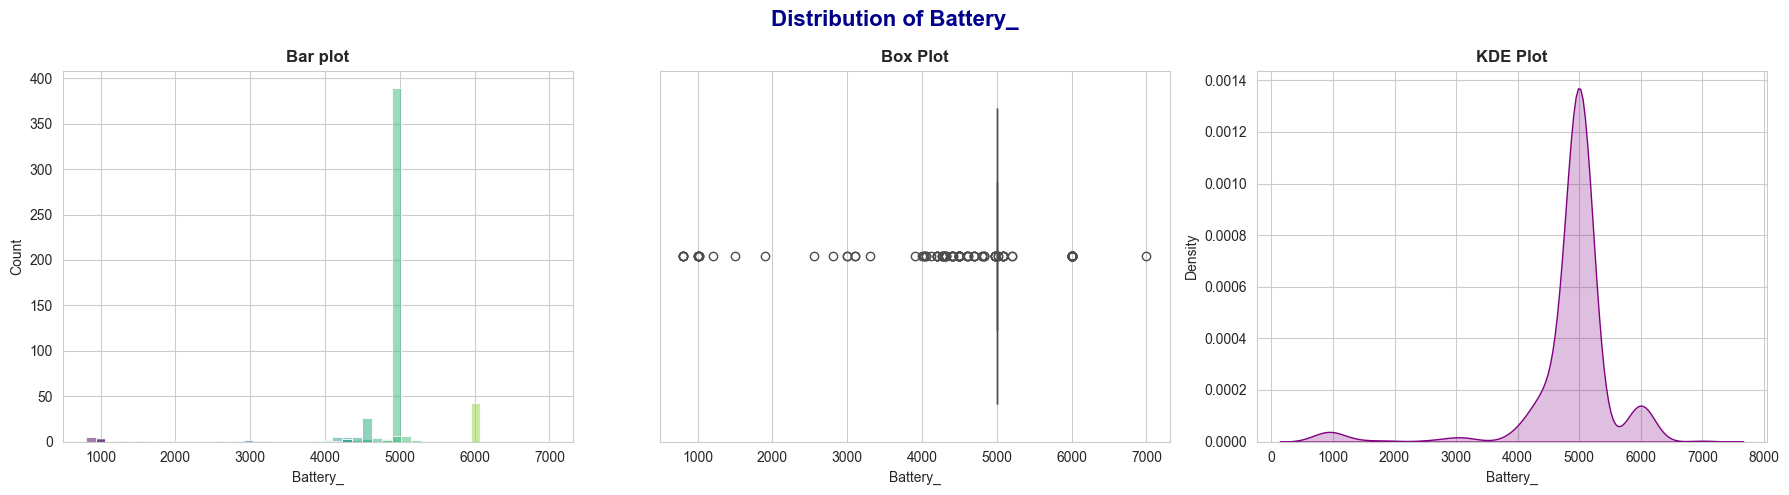

In [47]:
## Statistical Analysis
display(Markdown("## Statistical Analysis"))

display(Markdown("### Summary Statics"))
stat=df["Battery_"].describe().to_frame(name="Value").round(2)
stat.index=["Count","Mean","Std Dev","Min","25%","Median","75%","Max"]
display(stat)

# skewness and kurtosis
display(Markdown("### Skewness and Kurtosis"))
shape_stat= pd.DataFrame({
    "Metric":["Skewness","Kurtosis"],
    "Value":[df["Battery_"].skew(), df["Battery_"].kurt()]
})
shape_stat["Value"]=shape_stat["Value"].round(2) 
display(shape_stat)

# unique nos in battery column
print("Battery Unique No. Count: ", df["Battery_"].nunique())

# visualization

sns.set_style("whitegrid")
fig, ax=plt.subplots(1,3, figsize=(18,5))

# histogram

sns.histplot(x=df["Battery_"],ax=ax[0], palette="viridis",legend=False, hue=df["Battery_"])
ax[0].set_title("Bar plot", fontsize=12, fontweight="bold")


# box plot
sns.boxplot(x=df["Battery_"],ax=ax[1],color="orange")
ax[1].set_title("Box Plot", fontsize=12, fontweight="bold")

# kde plot
sns.kdeplot(x=df["Battery_"],ax=ax[2], fill=True, color="purple")
ax[2].set_title("KDE Plot", fontsize=12, fontweight="bold")

plt.suptitle("Distribution of Battery_", fontsize=16, fontweight="bold", color="darkblue")

plt.tight_layout()
plt.show()

### Distribution of Battery_

* The dataset contains **541 observations** of battery capacity.
* The **average battery** is around **4872**, indicating most devices fall in the mid-to-high battery range.
* The **median (5000)** , **25th percentile (5000)** and **75th percentile (5000)** are the same, showing a strong concentration at this value.
* The **minimum battery** is **800**, while the **maximum reaches 7000**, indicating a wide range of devices.

Skewness and Kurtosis

* The distribution is **highly left-skewed (Skewness = -3.30)**. Most values are clustered at higher battery capacities, with a few very low values pulling the tail to the left.
* The **kurtosis is very high (14.75)**. This indicates a **sharp peak (leptokurtic distribution)** with heavy tails, meaning:

**Histogram / KDE Plot**

- A **strong peak around 5000** confirms it is the most common battery capacity.
- Smaller peaks near **4000–4500 and 6000** suggest secondary clusters.

**Box Plot**

- Shows **multiple outliers**, especially on the lower end (below 3000 ).
- The box plot indicates several outliers; however it must study that,these corresponds to valid but less frequent Battery capacity or the anomalies. These can be validated by cross-checking with brand specification, model variants, and price ranges.

**kde Plot**
- The kde plot further confirms a non-normal distribution with strong central clustring

In [48]:
q1=df["Battery_"].quantile(0.25)
q3=df["Battery_"].quantile(0.75)

iqr=q3-q1

lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr

print("Lower Bound:",lower_bound)
print("Upper Bound:",upper_bound)

Lower Bound: 5000.0
Upper Bound: 5000.0


#### Because the dataset is dominated by the repeated value of 5000,the IQR methodnyield lower and upper bound both equall to 5000, classifying all non-5000 enteries are outliers

In [49]:
battery_counts=df["Battery_"].value_counts()
freq_group=battery_counts.groupby(battery_counts).apply(lambda x: list(x.index))

# print(freq_group)
for freq, values in freq_group.items():
    print(f"{freq} → {values}")

1 → [1900, 2550, 1200, 1500, 3300, 4000, 4030, 4115, 3110, 7000, 2815, 3900, 3100]
2 → [4410, 4020, 4800, 4610, 4050, 3000, 5020, 5200]
3 → [1020, 4600, 4270, 4323, 4830]
4 → [1000, 4700]
5 → [800, 4400, 4300, 4200]
6 → [5080, 4980]
26 → [4500]
42 → [6000]
389 → [5000]


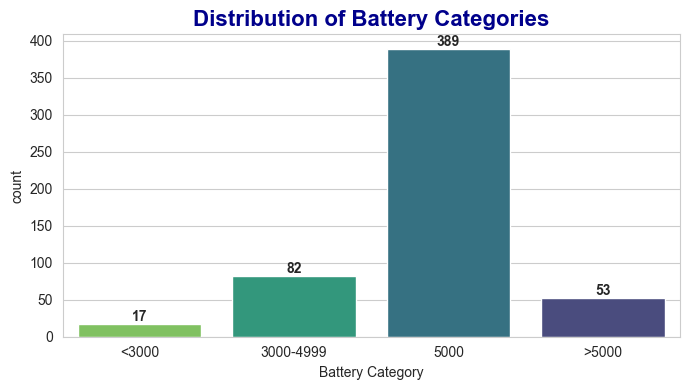

In [86]:
def battery_category(x):
    if x < 3000:
        return "<3000"
    elif x < 5000:
        return "3000-4999"
    elif x == 5000:
        return "5000"
    else:
        return ">5000"

df["Battery_Category"] = df["Battery_"].apply(battery_category)

order = ["<3000", "3000-4999", "5000", ">5000"]

plt.figure(figsize=(7,4))

ax = sns.countplot(x="Battery_Category", data=df,
                   order=order, palette="viridis",hue="Battery_Category", legend=False)

plt.title("Distribution of Battery Categories", fontsize=16, color="darkblue", fontweight="bold")
plt.xlabel("Battery Category")

# add labels (correctly)
for container in ax.containers:
    ax.bar_label(container, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

The dataset shows a highly concentrated distribution around 5000 , confirming it as the dominant market standard. While higher-capacity batteries (>5000 ) represent a smaller segment, they indicate a growing trend toward performance-oriented devices. Lower battery categories are minimal and largely represent outdated or less relevant devices.

## 4. Rear Camera

## Statistical Analysis

### Summary Statistics

,Rear Camera
Count,541.00
Mean,46.11
Std Dev,31.26
Min,0.00
25%,13.00
Median,50.00
75%,50.00
Max,200.00


## Skewness and Kurtosis

,Metric,Value
0,Skewness,1.80
1,Kurtosis,7.23


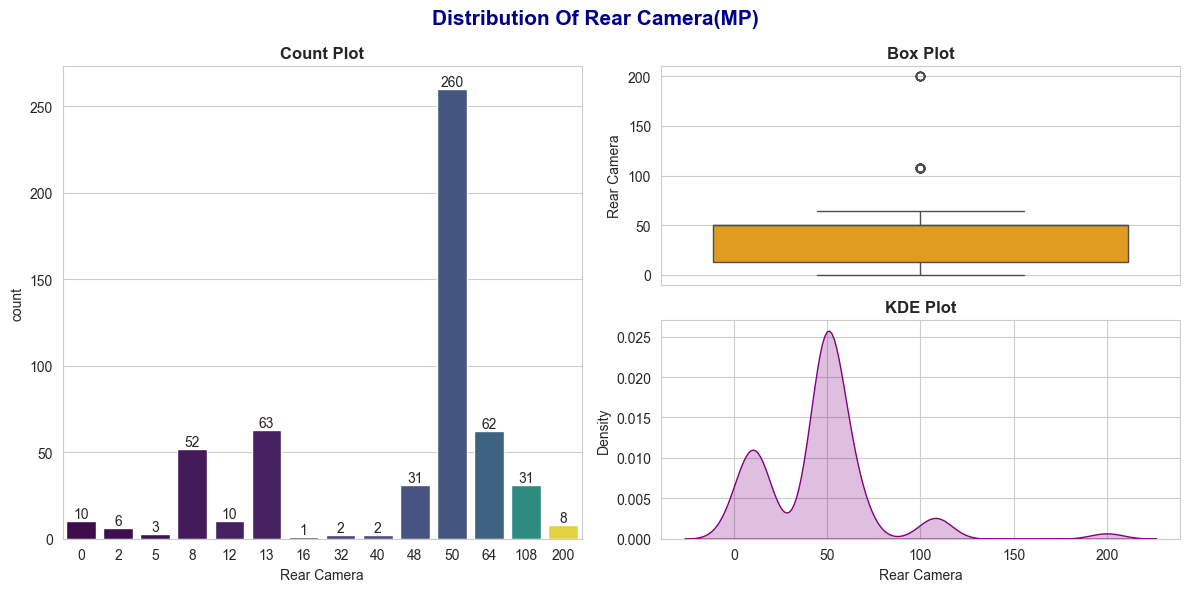

In [51]:
display(Markdown("## Statistical Analysis"))

display(Markdown("### Summary Statistics"))
stat=df["Rear Camera"].describe().round(2).to_frame()
stat.index=["Count","Mean","Std Dev","Min","25%","Median","75%","Max"]
display(stat)

# skewness and kurtosis
display(Markdown("## Skewness and Kurtosis"))
shape_stat=pd.DataFrame({
    "Metric":["Skewness","Kurtosis"],
    "Value":[df["Rear Camera"].skew(),df["Rear Camera"].kurt()]
})
shape_stat["Value"]=shape_stat["Value"].round(2)
display(shape_stat)

# Visualization
sns.set_style("whitegrid")

fig, ax=plt.subplots(2,2,figsize=(12,6))

# remove left column axes
fig.delaxes(ax[0, 0])
fig.delaxes(ax[1, 0])

#create big ax for histogram
big_ax=fig.add_subplot(1,2,1)

sns.countplot(x=df["Rear Camera"], ax=big_ax, hue=df["Rear Camera"], palette="viridis", legend=False)
big_ax.set_title("Count Plot", fontsize=12, fontweight="bold")

# labels
for container in big_ax.containers:
    big_ax.bar_label(container)

# boxplot
sns.boxplot(df["Rear Camera"], ax=ax[0,1], color="orange")
ax[0,1].set_title("Box Plot", fontsize=12, fontweight="bold")

# kde plot
sns.kdeplot(df["Rear Camera"], ax=ax[1,1], fill=True, color="purple")
ax[1,1].set_title("KDE Plot", fontsize=12, fontweight="bold")

plt.suptitle("Distribution Of Rear Camera(MP)", fontsize=15, fontweight="bold", color="darkblue")

plt.tight_layout()
plt.show()


##  Univariate Analysis of Rear Camera

Summary Statistics

* The dataset contains **541 observations**.
* The **mean camera resolution is 46.11 MP**, while the **median is 50 MP**, indicating that most devices are centered around 50 MP.
* The **standard deviation of 31.26 MP** shows moderate variability in camera specifications.
* The data ranges from **0 MP to 200 MP**, highlighting a wide spread of device categories.

---

Skewness and kurtosis
* The distribution is **positively skewed (Skewness = 1.80)**, meaning most devices have **moderate camera resolutions (around 50 MP)** and smaller number of devices have **very high resolutions (108 MP, 200 MP)**.

* The **kurtosis value of 7.23** indicates a **leptokurtic distribution** meaning a sharp peak around 50 MP and presence of  Presence of extreme values (heavy tails) which can confirm by kde plot.

---


* **Count Plot:**

  * A significant concentration at **50 MP (260 devices)**, making it the most common configuration.

* **Box Plot:**

  * Values such as **108 MP and 200 MP appear as outliers**. First study the data properly for these value and decide how to handle(to keep it as it is/ to remove it/ to cap these values) these values.

* **KDE Plot:**

  * A strong peak at **50 MP**, with smaller peaks at lower and higher resolutions.


In [52]:
Q1 = df['Rear Camera'].quantile(0.25)
Q3 = df['Rear Camera'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Rear Camera'] < lower) | (df['Rear Camera'] > upper)]
print(outliers["Rear Camera"].value_counts())

Rear Camera
108    31
200     8
Name: count, dtype: int64


#### Rear Camera value 108 appears in 31 devices while 200 appears in 8 devices show that theses are rare but valid cluster, not a single erroneous entries.

#### Also 108 and 200 are plausible technological extremes. They should be treated as high-end categories.

## 5. Front Camera

## Statistical Analysis

## Summary Statistics

,Front Camera
Count,541.00
Mean,11.99
Std Dev,9.05
Min,0.00
25%,5.00
Median,8.00
75%,16.00
Max,60.00


## Skewness and Kurtosis

,Metric,Value
0,Skewness,1.799491
1,Kurtosis,7.227342


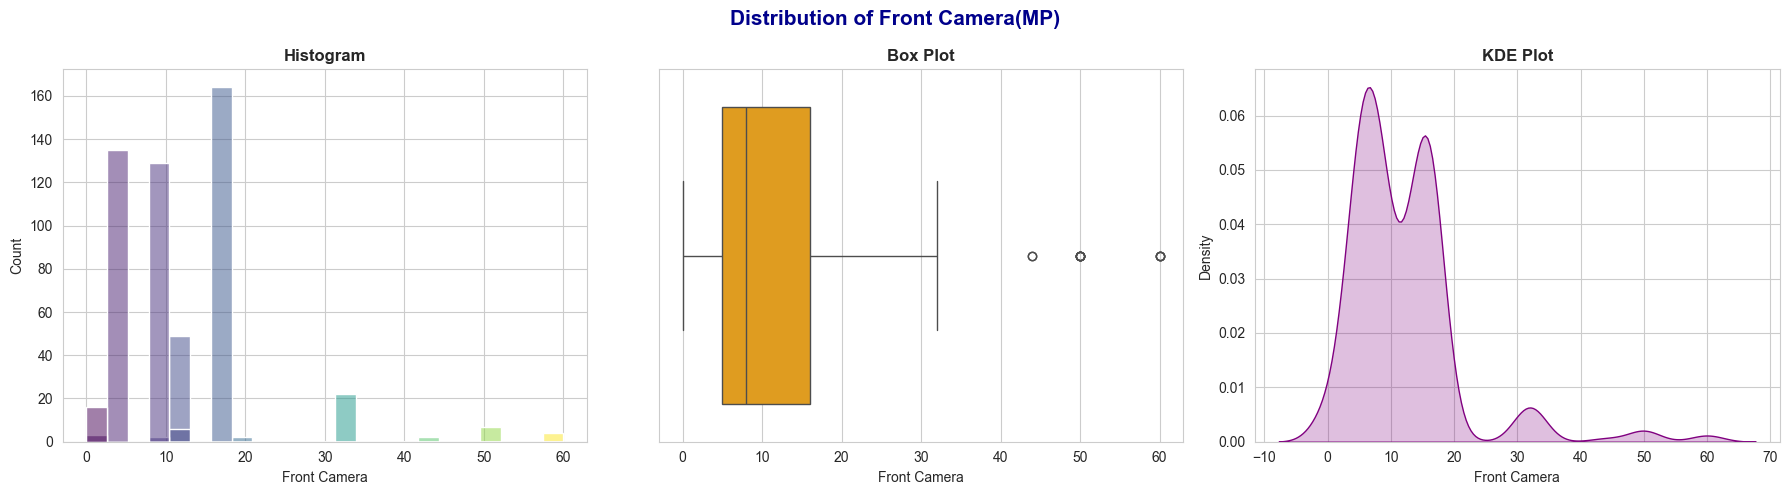

In [53]:
display(Markdown("## Statistical Analysis"))

display(Markdown("## Summary Statistics"))
stat=df["Front Camera"].describe().round(2).to_frame()
stat.index=["Count","Mean","Std Dev","Min","25%","Median","75%","Max"]
display(stat)

# skewness & Kurtosis
display(Markdown("## Skewness and Kurtosis"))
shape_stat= pd.DataFrame({
    "Metric": ["Skewness","Kurtosis"],
    "Value":[df["Rear Camera"].skew(),df["Rear Camera"].kurt()]
    })
shape_stat["Value"].round(2)
display(shape_stat)

# visualization
sns.set_style("whitegrid")

fig, ax=plt.subplots(1,3, figsize=(18,5))
sns.histplot(x=df["Front Camera"], ax=ax[0], hue=df["Front Camera"], palette="viridis", legend=False)
ax[0].set_title("Histogram", fontsize=12, fontweight="bold")

# boxplot
sns.boxplot(x=df["Front Camera"],ax=ax[1],color="orange")
ax[1].set_title("Box Plot", fontsize=12,fontweight="bold")

# kde plot
sns.kdeplot(x=df["Front Camera"], ax=ax[2], fill=True, color="purple")
ax[2].set_title("KDE Plot", fontsize=12, fontweight="bold")

plt.suptitle("Distribution of Front Camera(MP)", fontsize=15, fontweight="bold", color="darkblue")
plt.tight_layout()
plt.show()

In [54]:
Q1 = df['Front Camera'].quantile(0.25)
Q3 = df['Front Camera'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Front Camera'] < lower) | (df['Front Camera'] > upper)]

print(f"Interquartile Range (Q1–Q3): {Q1} to {Q3}")
print(f"Lower Bound: {lower}, Upper Bound: {upper}")

display(Markdown("### Outlier Counts for Front Camera"))
print(outliers["Front Camera"].value_counts())

Interquartile Range (Q1–Q3): 5.0 to 16.0
Lower Bound: -11.5, Upper Bound: 32.5


### Outlier Counts for Front Camera

Front Camera
50    7
60    4
44    2
Name: count, dtype: int64


### Outlier Detection and Handling in Front Camera

- Using IQR method, the valid range for front camera is 5-16 MP. Values of 44MP(2 devices), 50Mp(7 devices), and 60MP(4 devices) are statistically outliers, but they represent legitimate high end devices. However, the majority of devices fall within the 5-16MP range, which represent mainstream front camera specification.

## 6. AI Lens

### AI Lens Availability

AI_Lens_Label
No     507
Yes     34
Name: count, dtype: int64

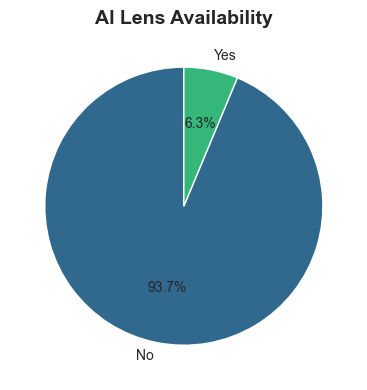

In [55]:
display(Markdown("### AI Lens Availability"))


df['AI_Lens_Label'] = df['AI Lens'].map({0: 'No', 1: 'Yes'})

# Value counts
counts = df['AI_Lens_Label'].value_counts()
display(counts)

sns.set_style("whitegrid")

plt.figure(figsize=(6,4))


colors = sns.color_palette("viridis", len(counts))

plt.pie(
    counts,
    labels=counts.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90
)

plt.title("AI Lens Availability", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### AI Lens Availability

The AI Lens feature shows a highly imbalanced distribution, with over 93% of devices lacking this capability. This suggests that AI Lens is not a common feature in the dataset and is likely limited to select smartphone models, making it more meaningful when analyzed alongside other attributes.

## 7. Prize

## Statistical Analysis

### Summary Statistics

,Prize
Count,541.00
Mean,16228.38
Std Dev,10793.59
Min,920.00
25%,9290.00
Median,13499.00
75%,19280.00
Max,80999.00


## Skewness and Kurtosis

,Metric,Value
0,Skewness,2.43
1,Kurtosis,9.61


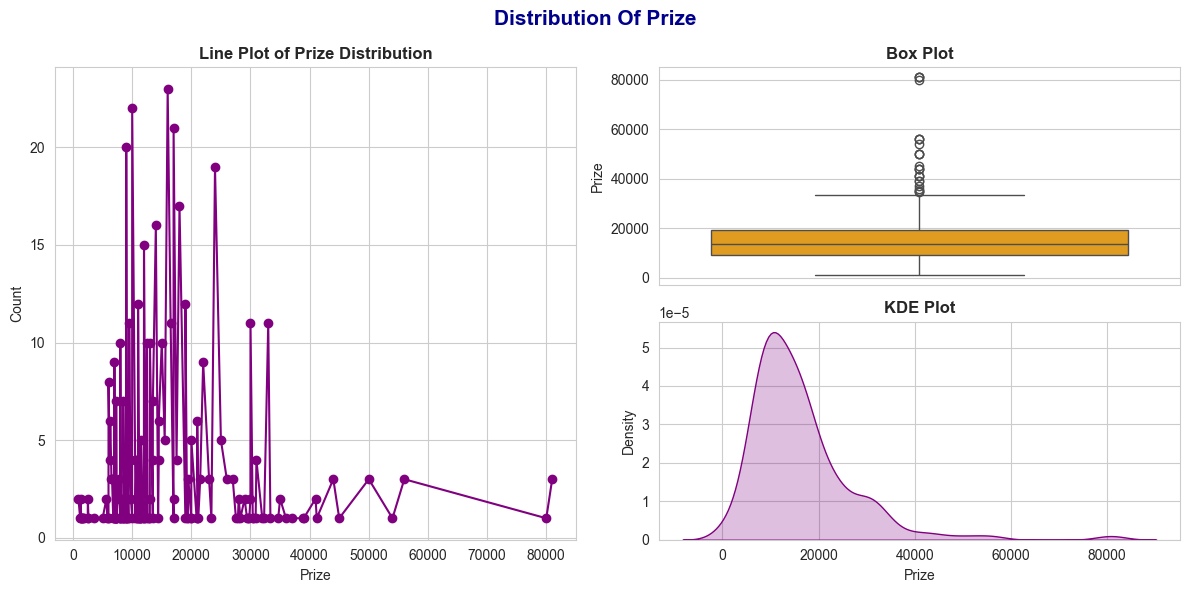

In [56]:
display(Markdown("## Statistical Analysis"))

display(Markdown("### Summary Statistics"))
stat=df["Prize"].describe().round(2).to_frame()
stat.index=["Count","Mean","Std Dev","Min","25%","Median","75%","Max"]
display(stat)

# skewness and kurtosis
display(Markdown("## Skewness and Kurtosis"))
shape_stat=pd.DataFrame({
    "Metric":["Skewness","Kurtosis"],
    "Value":[df["Prize"].skew(),df["Prize"].kurt()]
})
shape_stat["Value"]=shape_stat["Value"].round(2)
display(shape_stat)

# Visualization
sns.set_style("whitegrid")

fig, ax=plt.subplots(2,2,figsize=(12,6))

# remove left column axes

# Remove old axes
fig.delaxes(ax[0, 0])
fig.delaxes(ax[1, 0])

# Create big axis for line plot
big_ax = fig.add_subplot(1, 2, 1)

# Compute counts of Prize values
counts = df["Prize"].value_counts().sort_index()

# Line plot
big_ax.plot(counts.index, counts.values, marker='o', linestyle='-', color='purple')

# Title and labels
big_ax.set_title("Line Plot of Prize Distribution", fontsize=12, fontweight="bold")
big_ax.set_xlabel("Prize")
big_ax.set_ylabel("Count")


# boxplot
sns.boxplot(df["Prize"], ax=ax[0,1], color="orange")
ax[0,1].set_title("Box Plot", fontsize=12, fontweight="bold")

# kde plot
sns.kdeplot(df["Prize"], ax=ax[1,1], fill=True, color="purple")
ax[1,1].set_title("KDE Plot", fontsize=12, fontweight="bold")

plt.suptitle("Distribution Of Prize", fontsize=15, fontweight="bold", color="darkblue")

plt.tight_layout()
plt.show()

In [57]:
Q1 = df['Prize'].quantile(0.25)
Q3 = df['Prize'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Prize'] < lower) | (df['Prize'] > upper)]

print(f"Interquartile Range (Q1–Q3): {Q1} to {Q3}")
print(f"Lower Bound: {lower}, Upper Bound: {upper}")

display(Markdown("### Outlier Counts for Prize"))
print(outliers["Prize"].value_counts())

Interquartile Range (Q1–Q3): 9290.0 to 19280.0
Lower Bound: -5695.0, Upper Bound: 34265.0


### Outlier Counts for Prize

Prize
49999    3
43999    3
55999    3
80999    3
34999    2
40999    2
44999    1
36999    1
38920    1
41199    1
35999    1
34688    1
53999    1
79999    1
38999    1
Name: count, dtype: int64


### Distribution of Prize

The price distribution shows a **positively skewed (right-skewed)** pattern, as confirmed by a skewness value of 2.43. This indicates that while most smartphones are concentrated in the lower to mid-price range, a smaller number of high-priced devices extend the distribution toward the right.

The **mean (16,228)** is higher than the **median (13,499)**, further reinforcing the presence of high-value prices pulling the average upward. The interquartile range (9,290 to 19,280) highlights that the majority of devices fall within the **budget to mid-range segment**, which dominates the dataset.

The **high kurtosis value (9.61)** suggests a **leptokurtic distribution**, meaning:
- There is a strong central concentration of values  
- There are heavy tails, indicating the presence of extreme values  

### Interpretation Outliers

The box plot identifies several high-price points (above ~34,265) as outliers based on the IQR rule:

- **Lower Bound:** -5,695 (not meaningful in this context)
- **Upper Bound:** 34,265  

There are several values which lies out of the upper bound range and considered statistically as outliers. They are flagged because:
- The dataset is highly skewed  
- The majority of values lie in the mid-range  
- Premium devices (e.g., 40,000–80,000) are far from the median  

However:
- These values represent **legitimate premium and flagship smartphones**
- They are **expected and meaningful**, not errors or anomalies  
- Removing them would lead to **loss of important business insights**
- Instead create a new column of Price_Category for better understanding.

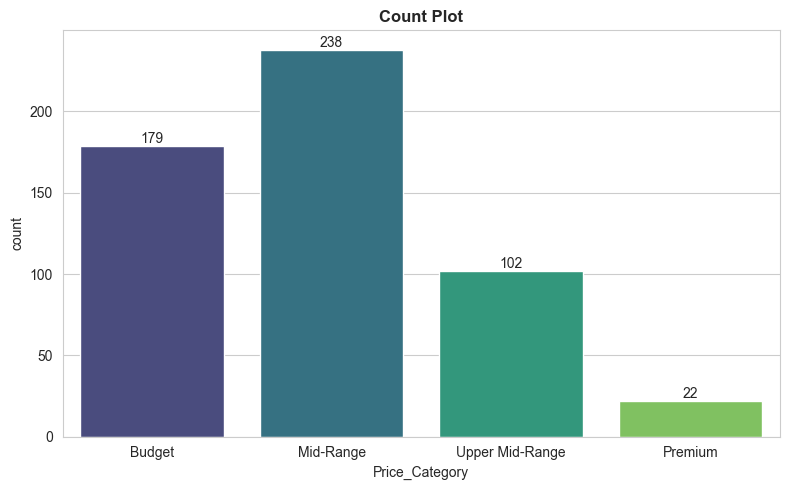

In [58]:
# Create Price Categories
def categorize_price(x):
    if x < 10000:
        return "Budget"
    elif x < 20000:
        return "Mid-Range"
    elif x < 35000:
        return "Upper Mid-Range"
    else:
        return "Premium"

df['Price_Category'] = df['Prize'].apply(categorize_price)

# Count plo
sns.set_style("whitegrid")

plt.figure(figsize=(8,5))
ax=sns.countplot(x=df["Price_Category"], hue=df["Price_Category"], palette="viridis", legend=False)
ax.set_title("Count Plot", fontsize=12, fontweight="bold")

# labels
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()


### Price Category Distribution 

#### The distribution of smartphones across price categories reveals a strong concentration in the **affordable segments**, with the Mid-Range category leading at 238 devices, followed by Budget at 179. This indicates that the dataset is heavily skewed toward cost-effective smartphones, reflecting typical consumer demand patterns in price-sensitive markets.

#### The Upper Mid-Range segment contains 102 devices, representing a moderate presence. This suggests a growing but still secondary demand for slightly premium features without entering the high-end category.

#### The Premium segment is significantly underrepresented, with only 22 devices. This highlights that high-end smartphones form a small portion of the dataset, reinforcing the earlier observation of right-skewness in price distribution.

## 8. Height

In [59]:
Q1 = df['Mobile Height'].quantile(0.25)
Q3 = df['Mobile Height'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

outliers = df[(df['Mobile Height'] < lower_bound) | (df['Mobile Height'] > upper_bound)]

print("Number of outliers:", len(outliers))
outliers['Mobile Height'].value_counts()

Q1: 16.51
Q3: 16.94
IQR: 0.4299999999999997
Lower Bound: 15.865000000000002
Upper Bound: 17.585
Number of outliers: 33


Mobile Height
4.50     7
15.49    6
6.10     5
41.94    2
15.60    2
4.57     2
13.84    2
7.11     1
5.08     1
15.46    1
15.70    1
15.80    1
17.65    1
12.70    1
Name: count, dtype: int64

### Outliers for Mobile Height 
- **Lower Bound**:15.865
- **Upper Bound**:17.585

#### Extreme low values like 4.50(7 times), 6.10(5 times), 4.57(2 times), 5.08, 7.11; these are not realastic mobile heights. Likely data entry errors, unit issues or misplaced values.

#### Extreame high values like 41.94(2 times); clearly invalid. no smartphone is ~42 cm tall. Must be wrong entry or mixed column issue

#### Borderline Outliers like 15.49, 15.60, 15.46, 15.70, 15.80, 17.65; these are slightly outside bounds but still realistic.

#### Mid range but unusal outliers like 12.70, 13.84; these are uncommon but possible could be older smaller phones or data inconsistency

In [60]:
# Remove clearly wrong values first
df.loc[(df['Mobile Height'] < 10) | (df['Mobile Height'] > 20), 'Mobile Height'] = None

# Then apply IQR clipping
df['Mobile Height'] = df['Mobile Height'].clip(lower_bound, upper_bound)

## Statistical Analysis

### Summary Statistics

,Mobile Height
Count,523.00
Mean,16.70
Std Dev,0.28
Min,15.87
25%,16.51
Median,16.76
75%,16.94
Max,17.58


## Skewness and Kurtosis

,Metric,Value
0,Skewness,-0.40
1,Kurtosis,1.05


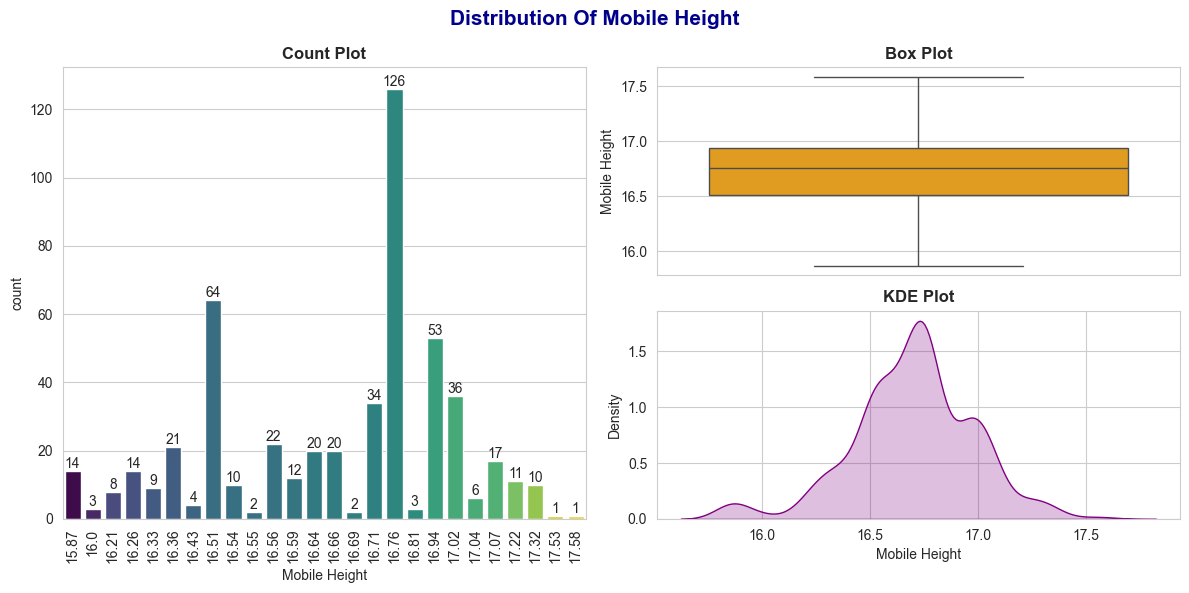

In [61]:
display(Markdown("## Statistical Analysis"))

display(Markdown("### Summary Statistics"))
stat=df["Mobile Height"].describe().round(2).to_frame()
stat.index=["Count","Mean","Std Dev","Min","25%","Median","75%","Max"]
display(stat)

# skewness and kurtosis
display(Markdown("## Skewness and Kurtosis"))
shape_stat=pd.DataFrame({
    "Metric":["Skewness","Kurtosis"],
    "Value":[df["Mobile Height"].skew(),df["Mobile Height"].kurt()]
})
shape_stat["Value"]=shape_stat["Value"].round(2)
display(shape_stat)

# Visualization
sns.set_style("whitegrid")

fig, ax=plt.subplots(2,2,figsize=(12,6))

# remove left column axes
fig.delaxes(ax[0, 0])
fig.delaxes(ax[1, 0])

#create big ax for histogram
big_ax=fig.add_subplot(1,2,1)

sns.countplot(x=df["Mobile Height"].round(2), ax=big_ax, hue=df["Mobile Height"], palette="viridis", legend=False)
big_ax.set_title("Count Plot", fontsize=12, fontweight="bold")
big_ax.tick_params(axis='x', rotation=90)

# labels
for container in big_ax.containers:
    big_ax.bar_label(container)

# boxplot
sns.boxplot(df["Mobile Height"], ax=ax[0,1], color="orange")
ax[0,1].set_title("Box Plot", fontsize=12, fontweight="bold")

# kde plot
sns.kdeplot(df["Mobile Height"], ax=ax[1,1], fill=True, color="purple")
ax[1,1].set_title("KDE Plot", fontsize=12, fontweight="bold")

plt.suptitle("Distribution Of Mobile Height", fontsize=15, fontweight="bold", color="darkblue")

plt.tight_layout()
plt.show()

### Univariate Analysis on Mobile Height

- Mean(16.70) and Median(16.76) are very close after capping the outliers values.
- Skewness is -0.40; Slightly left skewed meaning a few shorter devices are at lower range.
- Kurtosis 1.05 close to normal.

### Count plot
- 16.76 is the most common mobile height with 126 devices. It align with the median and the mode showing strong standardization.
- Other frequent values include:
    - 16.51 (64 devices)
    - 16.94 (53 devices)
    - 17.02 (36 devices)




## Bivariate Analysis


## 1. Memory

### Memory Vs Numerical Columns

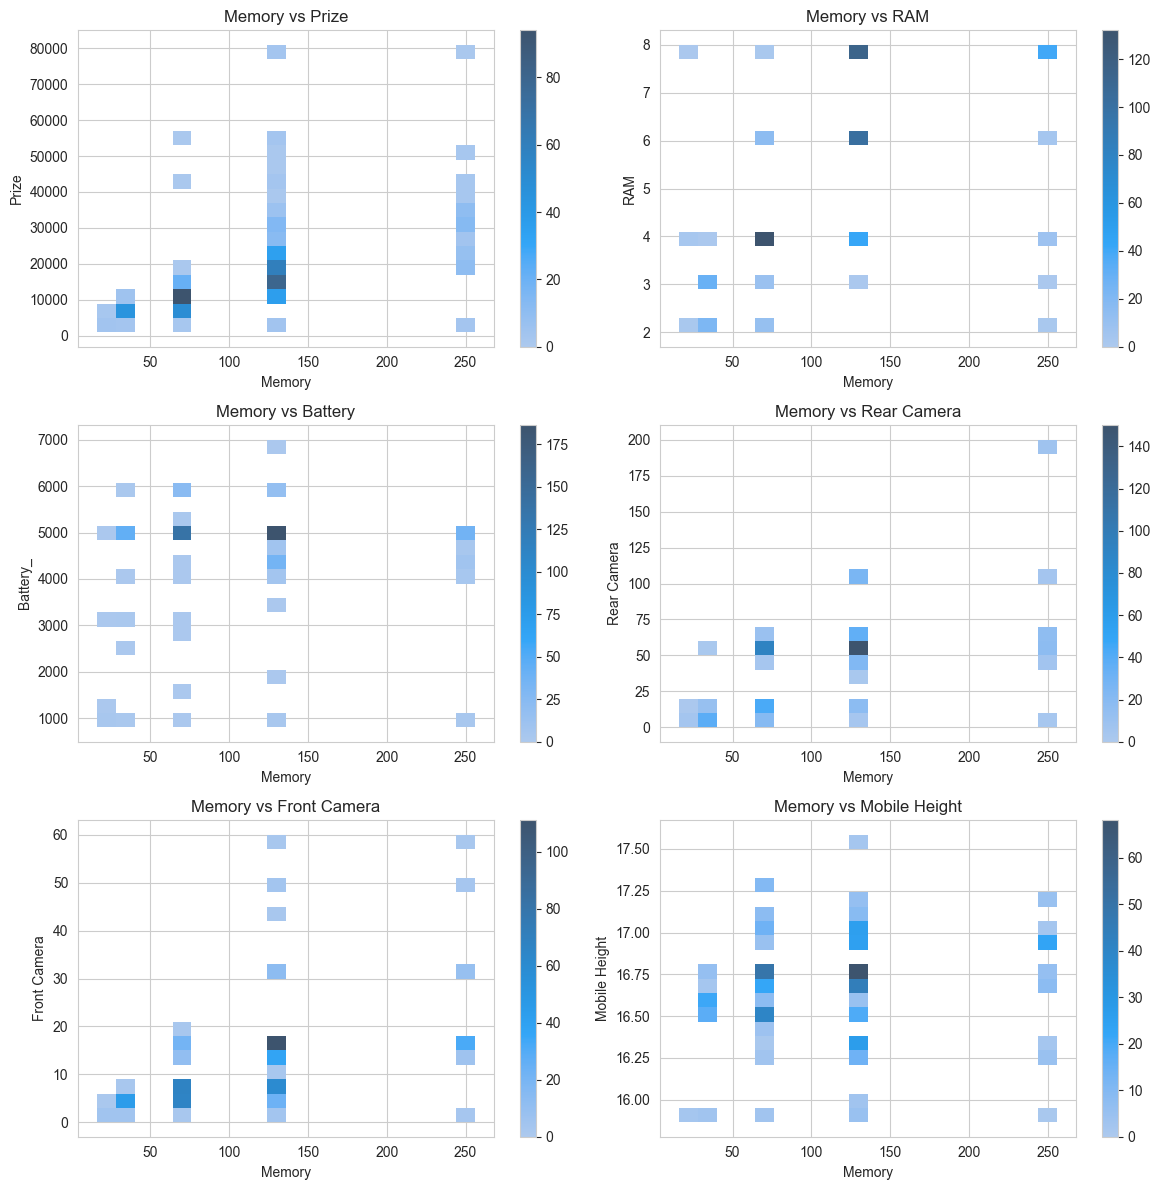

In [62]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(3, 2, figsize=(12, 12))

# 1. Memory vs Prize
sns.histplot(data=df, x="Memory", y="Prize", bins=20, cbar=True, ax=axes[0,0])
axes[0,0].set_title("Memory vs Prize")

# 2. Memory vs RAM
sns.histplot(data=df, x="Memory", y="RAM", bins=20, cbar=True, ax=axes[0,1])
axes[0,1].set_title("Memory vs RAM")

# 3. Memory vs Battery
sns.histplot(data=df, x="Memory", y="Battery_", bins=20, cbar=True, ax=axes[1,0])
axes[1,0].set_title("Memory vs Battery")

# 4. Memory vs Rear Camera
sns.histplot(data=df, x="Memory", y="Rear Camera", bins=20, cbar=True, ax=axes[1,1])
axes[1,1].set_title("Memory vs Rear Camera")

# 5. Memory vs Front Camera
sns.histplot(data=df, x="Memory", y="Front Camera", bins=20, cbar=True, ax=axes[2,0])
axes[2,0].set_title("Memory vs Front Camera")

# 6. Memory vs Mobile Height
sns.histplot(data=df, x="Memory", y="Mobile Height", bins=20, cbar=True, ax=axes[2,1])
axes[2,1].set_title("Memory vs Mobile Height")

plt.tight_layout()
plt.show()

### Memory vs Prize
- The heatmap shows dense clusters along a diagonal: higher memory aligns with higher prices.  
- The concentration in mid‑range bins suggests most devices are positioned in the affordable–mid tier.  
- Sparse but visible bins at high price with moderate memory highlight premium models differentiated by other specs.
- Strong density: Mid‑range memory (64–128 GB) with mid‑range prices (₹15k–₹25k).
- Weaker density: High price (>₹60k) with moderate memory (128 GB) — premium but less common

### Memory vs RAM
- Very strong diagonal density: storage and RAM scale together.  
- This confirms manufacturers bundle higher RAM with higher memory tiers.  
- Few off‑diagonal bins → consistency across product lines.
- Strongest density: Clear diagonal around 64–128 GB memory paired with 4–8 GB RAM.
- Weaker density: Off‑diagonal bins (e.g., high memory with low RAM) — rare configurations.

### Memory vs Battery
- Distribution is more diffuse: battery capacity doesn’t scale directly with memory.  
- Clusters appear at standard battery sizes (e.g., 3000–5000 ), independent of storage.  
- Indicates battery design is constrained by form factor rather than storage tier.
- Strongest density: Memory 64–128 GB with battery ~5000  (the mainstream cluster).
- Weaker density: Very high battery (>6000 ) with mid memory — niche endurance phones.

### Memory vs Rear Camera
- Moderate diagonal trend: higher memory often pairs with stronger rear cameras.  
- Dense bins at mid‑range memory and mid‑range camera specs show mainstream balance.  
- Outliers (high camera resolution with modest memory) suggest camera‑centric budget phones.
- Strongest density: Memory 64–128 GB with rear camera ~48–64 MP.
- Weaker density: Ultra‑high camera (108–200 MP) with mid memory — fewer but notable.

### Memory vs Front Camera
- Much weaker correlation: density is spread horizontally.  
- Front camera specs plateau regardless of memory tier.  
- Suggests selfie cameras are capped at mid‑range resolutions across devices.
- Strongest density: Memory 64–128 GB with front camera ~16 MP.
- Weaker density: High front camera (>32 MP) with mid memory — rare, selfie‑centric models.

### Memory vs Mobile Height
- No clear diagonal: density clusters around standard heights (14-16).  
- Memory distribution is broad across these bins, showing physical size is independent of storage.  
- Outliers (very tall phones) don’t show a consistent memory pattern.
- Strongest density: Memory 64–128 GB with height ~155–160 mm (standard smartphone size).
- Weaker density: Very tall phones (>170 mm) with varied memory — phablets, less frequent.

### Memory Vs Categorical columns

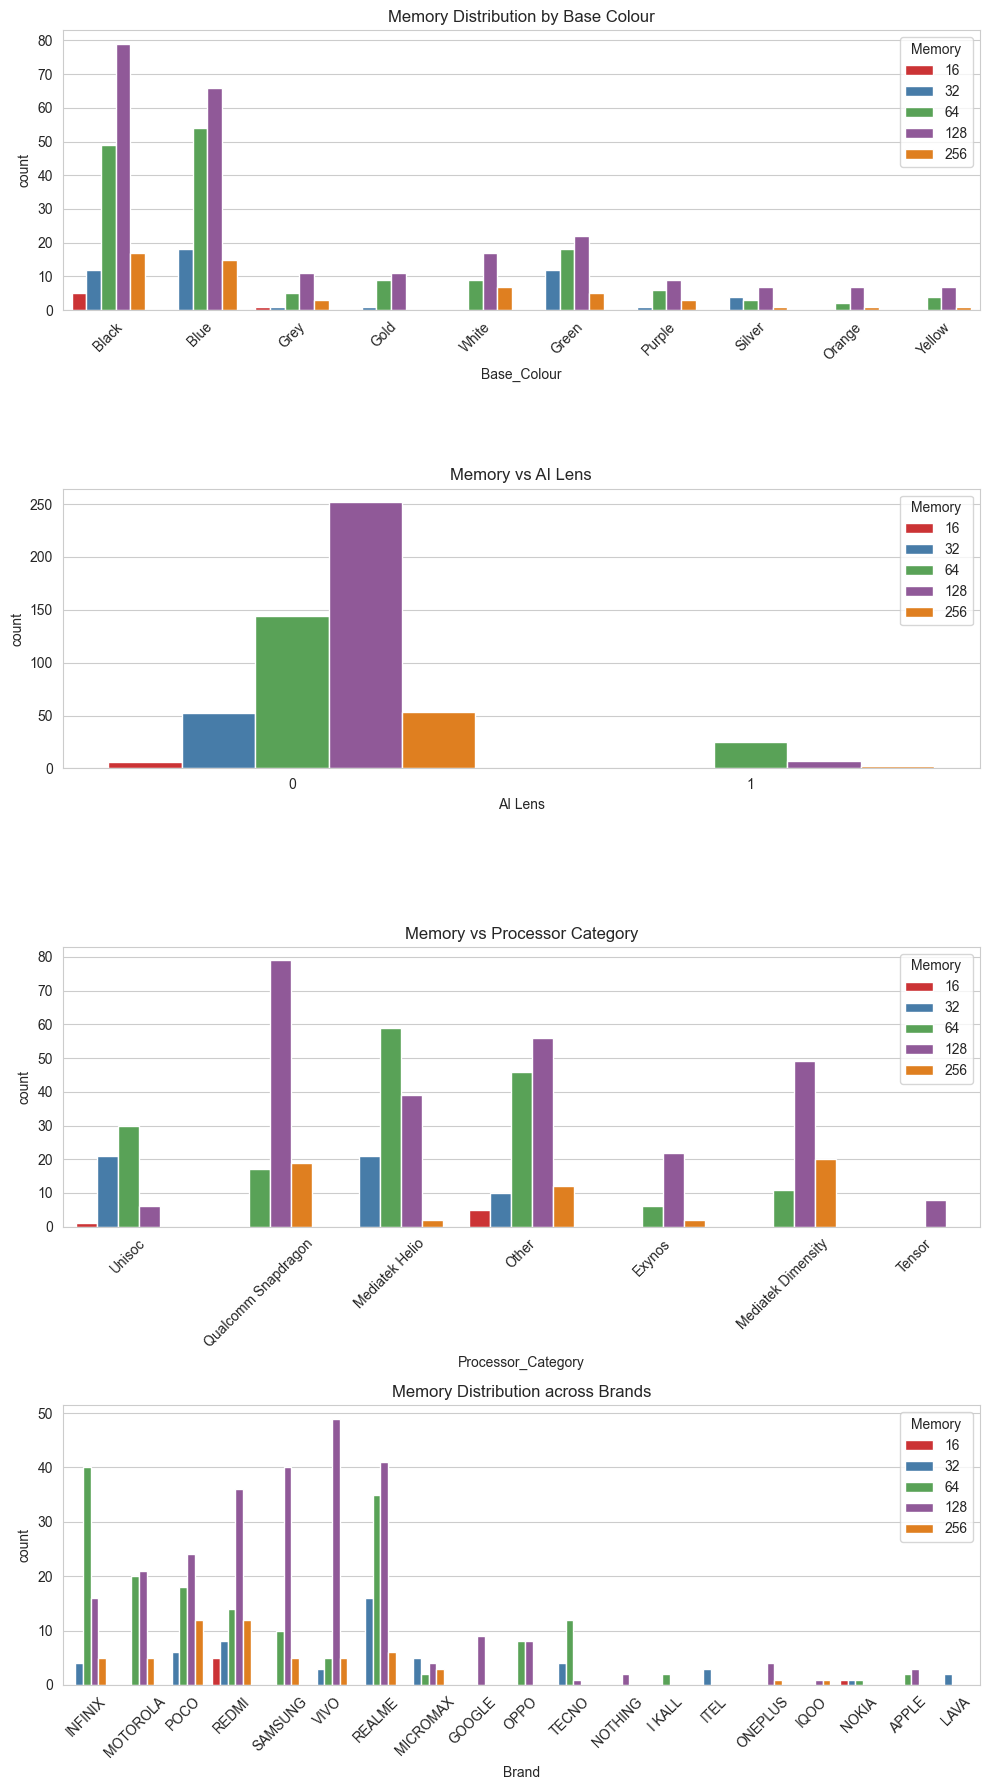

In [63]:
sns.set_style("whitegrid")

#Filter Top 10 Base Colours
top_colors = df["Base_Colour"].value_counts().head(10).index
df_color = df[df["Base_Colour"].isin(top_colors)]

# Create Subplots 
fig, axes = plt.subplots(4, 1, figsize=(10, 18))

# 1. Memory vs Base Colour
sns.countplot(x="Base_Colour", hue="Memory", data=df_color,
              palette="Set1", ax=axes[0])
axes[0].set_title("Memory Distribution by Base Colour")
axes[0].tick_params(axis='x', rotation=45)

# 2. Memory vs AI Lens
sns.countplot(x="AI Lens", hue="Memory", data=df,
              palette="Set1", ax=axes[1])
axes[1].set_title("Memory vs AI Lens")

# 3. Memory vs Processor Category
sns.countplot(x="Processor_Category", hue="Memory", data=df,
              palette="Set1", ax=axes[2])
axes[2].set_title("Memory vs Processor Category")
axes[2].tick_params(axis='x', rotation=45)

# 4. Memory vs Brand
sns.countplot(x="Brand", hue="Memory", data=df,
              palette="Set1", ax=axes[3])
axes[3].set_title("Memory Distribution across Brands")
axes[3].tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()

# 1. Memory vs Base Colour
* **Black & Blue dominate across all memory variants**, especially **128GB and 64GB**
* Rare colours (Gold, Purple, Orange, Yellow) have **very limited availability**
* **Higher memory (128GB, 256GB)** is mostly offered in Black and Blue colour.

# 2. Memory vs AI Lens 
* Majority of phones are **AI Lens = 0 (No AI)**
* Even in **128GB (largest segment)** → AI is mostly absent
* AI presence is slightly visible in **64GB**, but still very low overall.
> AI Lens adoption is minimal and does not scale with increasing memory, indicating that AI features depend more on hardware capability than storage configuration.

# 3. Memory vs Processor
* **Snapdragon & Dimensity**: Strong presence in **128GB and 256GB**
* **Mediatek Helio**: Concentrated in **64GB and 128GB**
* **Unisoc**: Mostly **32GB and 64GB (low-end)**
* **Tensor / Exynos**: Limited but mostly **higher memory (128GB)**

* Clear **segmentation pattern**:

  * Budget → Unisoc, Helio + low memory
  * Mid-range → Helio, Dimensity + 64/128
  * Premium → Snapdragon, Dimensity + 128/256
> Memory configuration is strongly aligned with processor category, indicating a structured product segmentation strategy where higher storage variants are paired with more powerful chipsets.

# 4. Memory vs Brand 

* **128GB is the most common across almost all brands**. This is the **industry standard**
* **Infinix, Lava, Micromax**: More **64 / 32**,  Very few 128+
* **Realme, Redmi, Poco**: Strong in **64 + 128**, Some 256GB
* **Samsung, Vivo, Oppo**: Heavy focus on **128**. Also offer **256 variants**
* **OnePlus, Apple**: Mostly **128 and above**. Very limited low-memory variants


> The analysis reveals that memory configuration plays a central role in smartphone segmentation. While colour and AI Lens features show minimal dependence on memory, processor category and brand positioning exhibit strong alignment. Higher memory variants (128 and above) are predominantly paired with advanced processors such as Snapdragon and Dimensity, reinforcing a structured approach to product differentiation. Additionally, 128 emerges as the industry standard across most brands, with budget brands focusing on lower memory configurations and premium brands offering higher storage options. Overall, memory acts as a key linking feature that reflects both hardware capability and market positioning.

## 2.  RAM

### RAM vs Numerical Columns

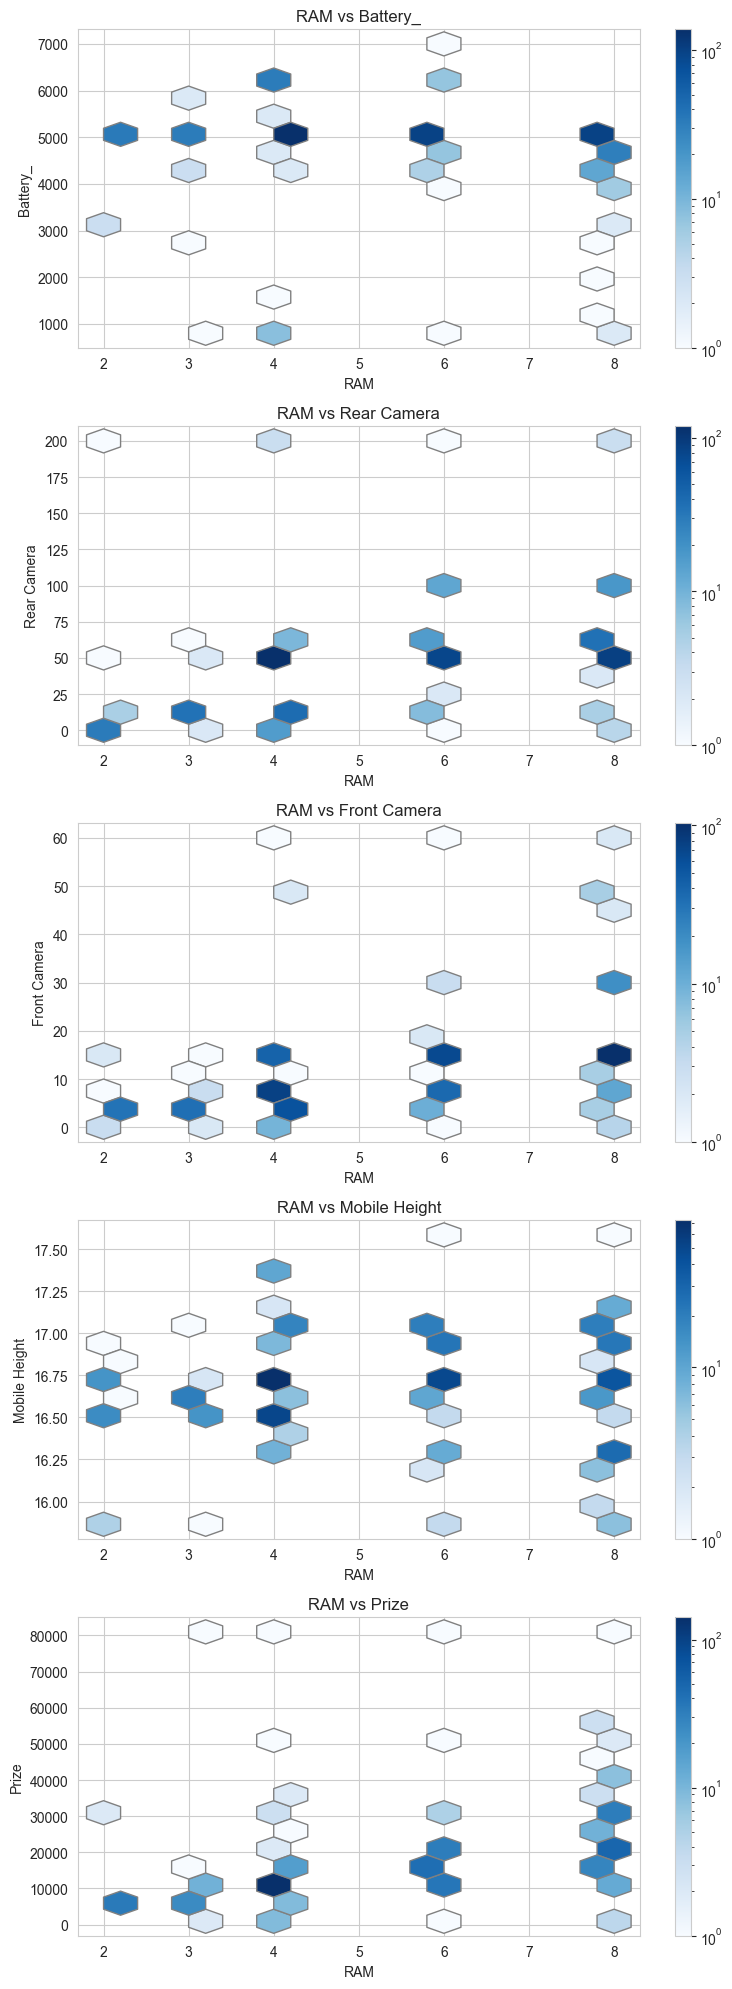

In [64]:
cols = ["Battery_", "Rear Camera",
        "Front Camera", "Mobile Height", "Prize"]

fig, axes = plt.subplots(len(cols), 1, figsize=(8, 20))

for i, col in enumerate(cols):
    hb = axes[i].hexbin(df["RAM"], df[col],
                        gridsize=15,
                        cmap="Blues",
                        bins='log',
                        mincnt=1,
                        edgecolors='grey')
    
    axes[i].set_title(f"RAM vs {col}")
    axes[i].set_xlabel("RAM")
    axes[i].set_ylabel(col)
    
    fig.colorbar(hb, ax=axes[i])

plt.tight_layout()
plt.show()

## RAM vs Battery 
- **Strongest density**: Mid‑range RAM (4–6) with ~4000–5000 batteries → mainstream balance.  
- **Weaker density**: High RAM (8) with very large batteries (>6000 ) → niche endurance models.

## RAM vs Rear Camera
- **Strongest density**: 4–6 RAM with ~48–64 MP rear cameras → common mid‑tier devices. 8 RAM also shows density around 50-100 MP rear camera.
- **Weaker density**: 8 GB RAM with ultra‑high cameras (108–200 MP) → premium but less frequent.

## RAM vs Front Camera 
- **Strongest density**: 4–8 RAM with ~16 MP front cameras → mainstream cluster.  
- **Weaker density**: 8 GB RAM with >32 MP front cameras → rare selfie‑centric phones.

## RAM vs Mobile Height
- **Strongest density**: 4–6 GB RAM with ~155–160 mm height → standard smartphone dimensions.  
- **Weaker density**: 8 GB RAM with >170 mm height → phablets, less common.

## RAM vs Prize
- **Strongest density**: 4–6 GB RAM with mid‑range prices (₹15k–₹25k).  
- **Weaker density**: 8 GB RAM with ultra‑premium prices (>₹60k) → fewer but high‑end devices.

>**Mainstream cluster**: 4–6 GB RAM is the market’s center of gravity, consistently paired with mid‑range prices, ~4000–5000 mAh batteries, 48–64 MP rear cameras, 16 MP front cameras, and ~155–160 mm height.  
>**Premium/niche cluster**: 8 GB RAM devices break away from this density, appearing in high‑price segments, with ultra‑high rear cameras, oversized batteries, or phablet dimensions.  
>**Interpretation**: RAM, like memory, is a **tier marker**. Mid‑range RAM defines mainstream density hotspots, while higher RAM values signal premium differentiation strategies.

### RAM vs Categorical Coulmns

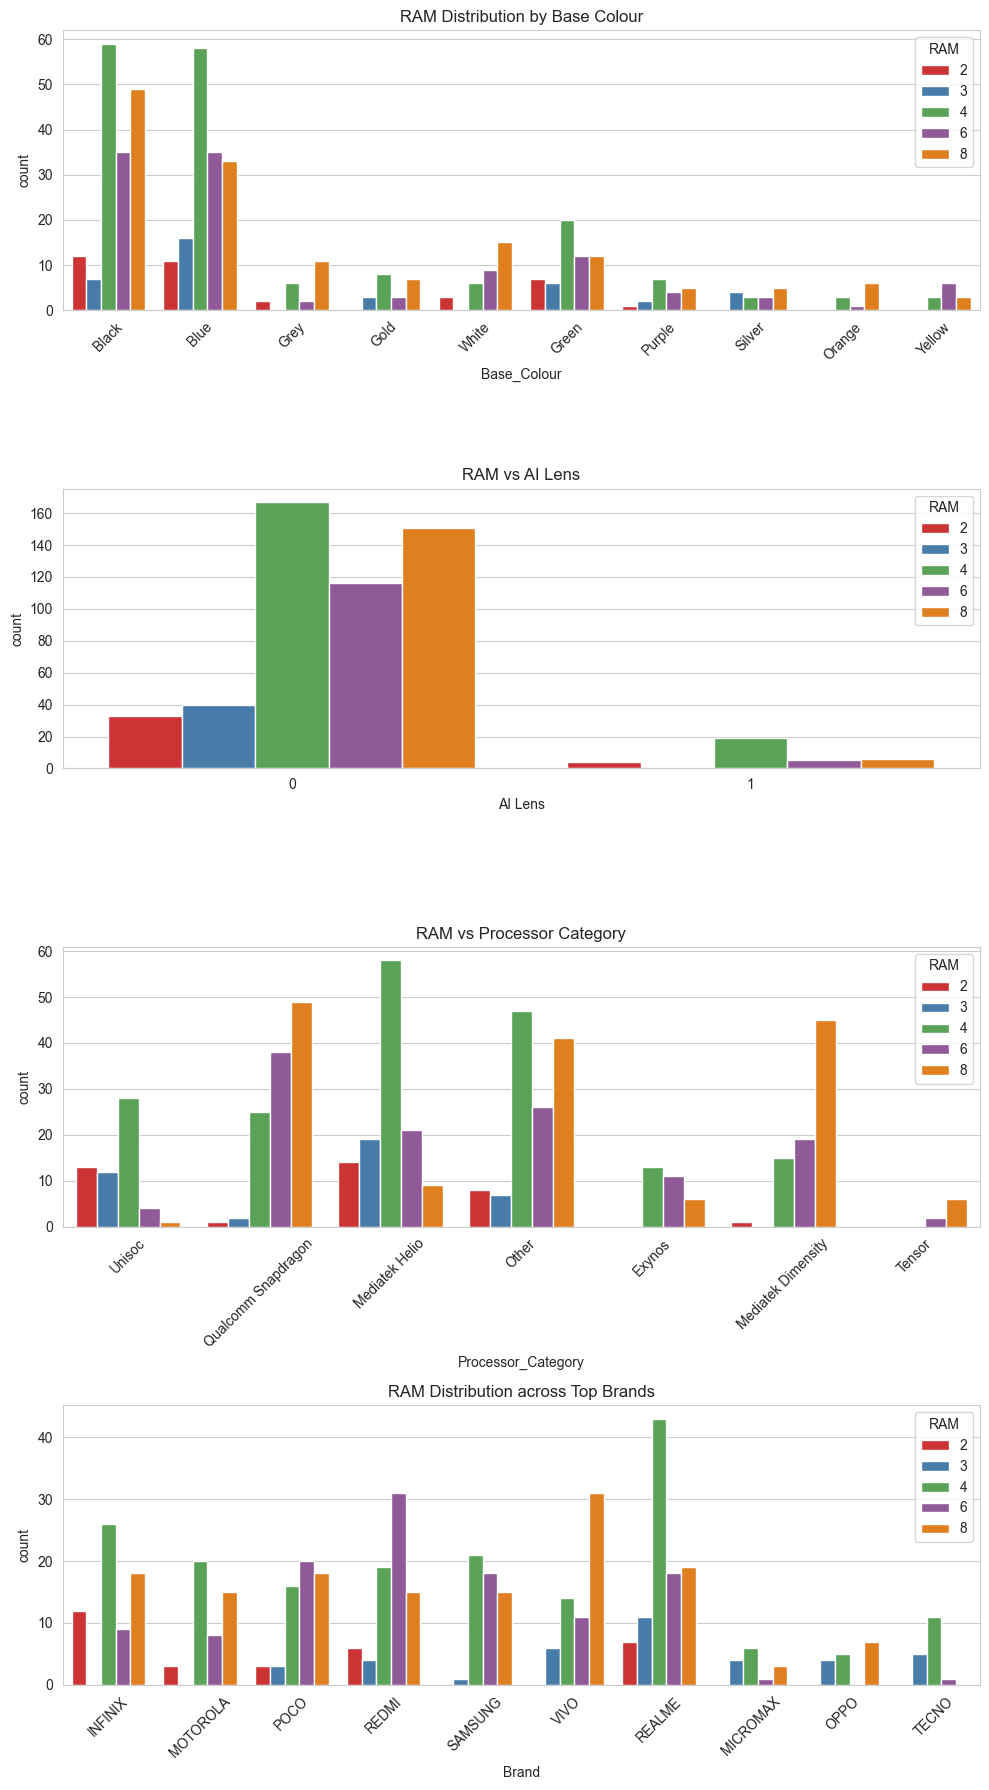

In [65]:
sns.set_style("whitegrid")

# Filter Top 10 Base Colours 
top_colors = df["Base_Colour"].value_counts().head(10).index
df_color = df[df["Base_Colour"].isin(top_colors)]

# Filter Top 10 Brands
top_brands = df["Brand"].value_counts().head(10).index
df_brand = df[df["Brand"].isin(top_brands)]

# Create Subplots 
fig, axes = plt.subplots(4, 1, figsize=(10, 18))

# 1. RAM vs Base Colour
sns.countplot(x="Base_Colour", hue="RAM", data=df_color,
              palette="Set1", ax=axes[0])
axes[0].set_title("RAM Distribution by Base Colour")
axes[0].tick_params(axis='x', rotation=45)

# 2. RAM vs AI Lens
sns.countplot(x="AI Lens", hue="RAM", data=df,
              palette="Set1", ax=axes[1])
axes[1].set_title("RAM vs AI Lens")

# 3. RAM vs Processor Category
sns.countplot(x="Processor_Category", hue="RAM", data=df,
              palette="Set1", ax=axes[2])
axes[2].set_title("RAM vs Processor Category")
axes[2].tick_params(axis='x', rotation=45)

# 4. RAM vs Brand
sns.countplot(x="Brand", hue="RAM", data=df_brand,
              palette="Set1", ax=axes[3])
axes[3].set_title("RAM Distribution across Top Brands")
axes[3].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 1. RAM vs Base Colour 
* **Black & Blue dominate across all RAM variants**, especially **4 and 6(highest frequency)**
* Higher RAM (6, 8) is mostly available in **safe colours (Black, Blue, White)**
* Rare colours (Gold, Orange, Yellow) have **very limited high-RAM options**

# 2. RAM vs AI Lens 
* Majority of devices → **AI Lens = 0 (No AI)**
* Even **6 and 8 RAM phones mostly don’t have AI Lens**
* Slight presence of AI in **4**, but still very low

# 3. RAM vs Processor
* **Unisoc**: Mostly **2–4**. Almost no high RAM
* **Mediatek Helio**: Strong in **4**. Some 6, very little 
* **Snapdragon**: Dominates **6 and 8**
* **Dimensity**: Strong presence in **6 & 8**
* **Tensor / Exynos**: Mostly **6+**
>Budget → low RAM + weak processor
>Premium → high RAM + powerful processor

# 4. RAM vs Brand
* **4 RAM = most common**
* Followed by **6 and 8**

* **Infinix, Micromax, Tecno**: Mostly **2–4**, limited high RAM
* **Poco, Motorola**: Balanced **4–6**. Some 8 RAM
* **Redmi, Realme**: Strong in **6 & 8**, Wide distribution
* **Samsung, Vivo, Oppo**: Focus on **6–8**. Minimal low RAM


> The analysis shows that RAM plays a critical role in smartphone segmentation and is strongly aligned with processor capability and brand positioning. While colour and AI Lens features exhibit minimal dependence on RAM, processor categories such as Snapdragon and Dimensity are closely associated with higher RAM configurations, indicating performance-oriented design strategies. Additionally, 4GB emerges as the industry standard, with 6GB and 8GB representing higher performance tiers. Budget brands focus on lower RAM configurations, whereas premium and performance-oriented brands emphasize higher RAM variants. Overall, RAM serves as a key indicator of device performance and market positioning.

## Battery_

### Battery Vs Numerical columns

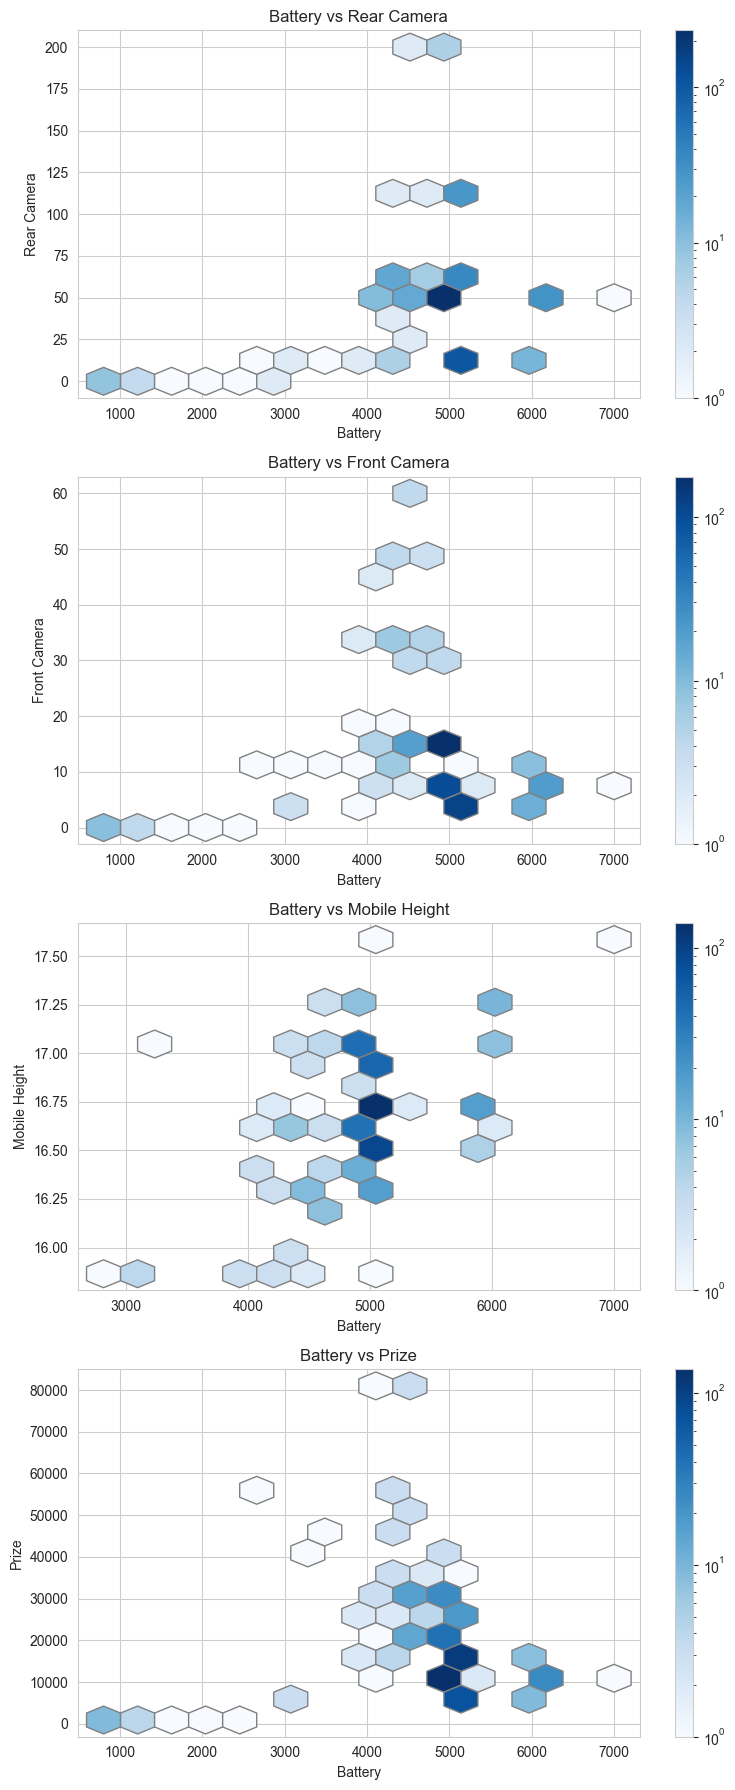

In [66]:
cols = ["Rear Camera",
        "Front Camera", "Mobile Height", "Prize"]

fig, axes = plt.subplots(len(cols), 1, figsize=(8, 18))

for i, col in enumerate(cols):
    hb = axes[i].hexbin(df["Battery_"], df[col],
                        gridsize=15,
                        cmap="Blues",
                        bins='log',
                        mincnt=1,
                        edgecolors='grey')
    
    axes[i].set_title(f"Battery vs {col}")
    axes[i].set_xlabel("Battery")
    axes[i].set_ylabel(col)
    
    fig.colorbar(hb, ax=axes[i])

plt.tight_layout()
plt.show()

## Battery vs Rear Camera
- **Strongest density**: 4000–6000  batteries with ~25–75 MP rear cameras → mainstream balance.  
- **Weaker density**: Ultra‑high cameras (108–200 MP) with mid batteries → premium but less frequent.

## Battery vs Front Camera
- **Strongest density**: 4000–6000  batteries with ~10–20 MP front cameras → mainstream cluster.  
- **Weaker density**: High front cameras (>32 MP) with mid batteries → rare selfie‑centric devices.

## Battery vs Mobile Height
- **Strongest density**: 4000–6000  batteries with ~16.5–17.25  height → standard smartphone dimensions.  
- **Weaker density**: Very tall phones (>17.5) with large batteries → niche phablets.

## Battery vs Prize  
- **Strongest density**: 4000–6000 mAh batteries with prices ₹10k–₹30k → mainstream affordability cluster.  
- **Weaker density**: High prices (>₹60k) with mid batteries → premium flagships where battery isn’t the differentiator.

>Battery capacity clusters strongly around **4000–6000**, forming the mainstream density hotspot across all features. This range defines the market’s “sweet spot,” balancing endurance with affordability, mid‑tier cameras, and standard dimensions.  

### Battery_ vs Categorical Columns

In [67]:
df["Battery_Category"] = pd.cut(df["Battery_"],
                            bins=[0, 3000, 4000, 5000, 6000, 8000],
                            labels=["<3000", "3000-4000", "4000-5000",
                                    "5000-6000", "6000+"])

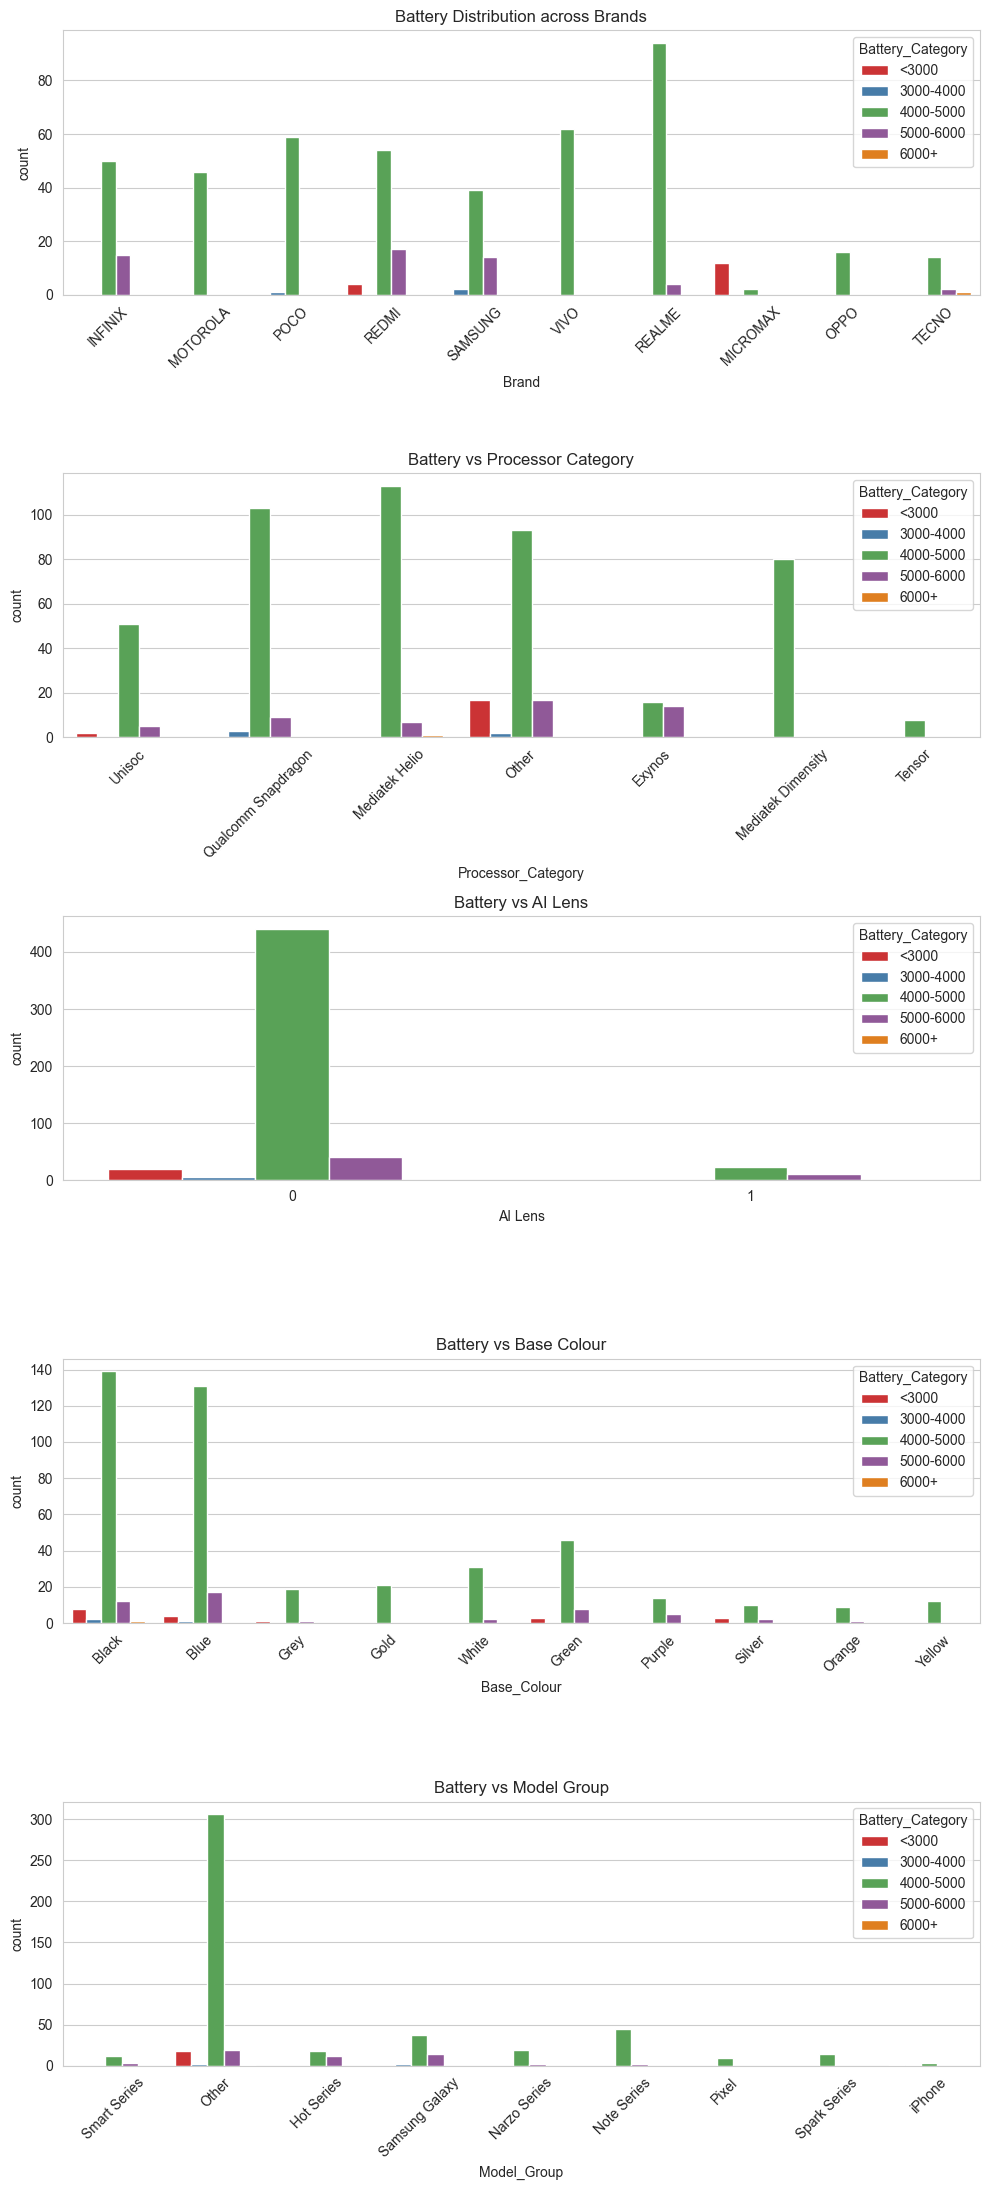

In [68]:
sns.set_style("whitegrid")

# Filter top categories
top_colors = df["Base_Colour"].value_counts().head(10).index
df_color = df[df["Base_Colour"].isin(top_colors)]

top_brands = df["Brand"].value_counts().head(10).index
df_brand = df[df["Brand"].isin(top_brands)]

fig, axes = plt.subplots(5, 1, figsize=(10, 22))

# 1. Battery vs Brand
sns.countplot(x="Brand", hue="Battery_Category", data=df_brand,
              palette="Set1", ax=axes[0])
axes[0].set_title("Battery Distribution across Brands")
axes[0].tick_params(axis='x', rotation=45)

# 2. Battery vs Processor
sns.countplot(x="Processor_Category", hue="Battery_Category", data=df,
              palette="Set1", ax=axes[1])
axes[1].set_title("Battery vs Processor Category")
axes[1].tick_params(axis='x', rotation=45)

# 3. Battery vs AI Lens
sns.countplot(x="AI Lens", hue="Battery_Category", data=df,
              palette="Set1", ax=axes[2])
axes[2].set_title("Battery vs AI Lens")

# 4. Battery vs Base Colour
sns.countplot(x="Base_Colour", hue="Battery_Category", data=df_color,
              palette="Set1", ax=axes[3])
axes[3].set_title("Battery vs Base Colour")
axes[3].tick_params(axis='x', rotation=45)

# 5. Battery vs Model Group
sns.countplot(x="Model_Group", hue="Battery_Category", data=df,
              palette="Set1", ax=axes[4])
axes[4].set_title("Battery vs Model Group")
axes[4].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 1. Battery vs Brand
* **4000–5000 dominates across ALL brands**.  This is clearly the **industry standard**
* **Realme, Vivo, Poco, Redmi**: Very strong concentration in 4000–5000 → mass-market focus
* **Samsung**:More spread → includes 5000–6000 range → slightly premium flexibility
* **Micromax**: Noticeable presence in **<3000** → outdated / budget segment

>Battery capacity is **highly standardized across brands**
>Differences exist only at **extremes (low or very high battery)**

# 2. Battery vs Processor 
* Across ALL processors → **4000–5000  dominates**

> Battery capacity is optimized for **efficiency**, not just performance level

# 3. Battery vs AI Lens 
* AI Lens = 1 phones are **very few**
* Those that exist still mostly fall in **4000–5000 **
* No visible pattern difference vs non-AI phones

# 4. Battery vs Base Colour
* Across all colours → **4000–5000 dominates** Black & Blue: Highest volume (because they are most common overall)
* Fo Rare colours there are limited data but still same battery trend

# 5. Battery vs Model Group 

* “Other” category (most models) → heavily **4000–5000**
* Series-based models (Galaxy, Note, Narzo): Slight presence of **5000–6000**
* Very few models in **6000+**
> The analysis reveals that battery capacity is one of the most standardized features across the smartphone dataset. Regardless of brand, processor type, AI capability, colour, or model grouping, the majority of devices fall within the 4000–5000 mAh range. This indicates an industry-wide optimization strategy balancing battery life, device weight, and cost. While minor variations exist in premium segments and specific model series, battery capacity does not serve as a primary differentiator, unlike features such as processor or memory. Instead, it acts as a baseline feature consistently maintained across all market segments.*


## 4. Rear Camera

### Rear Camera vs Numerical columns

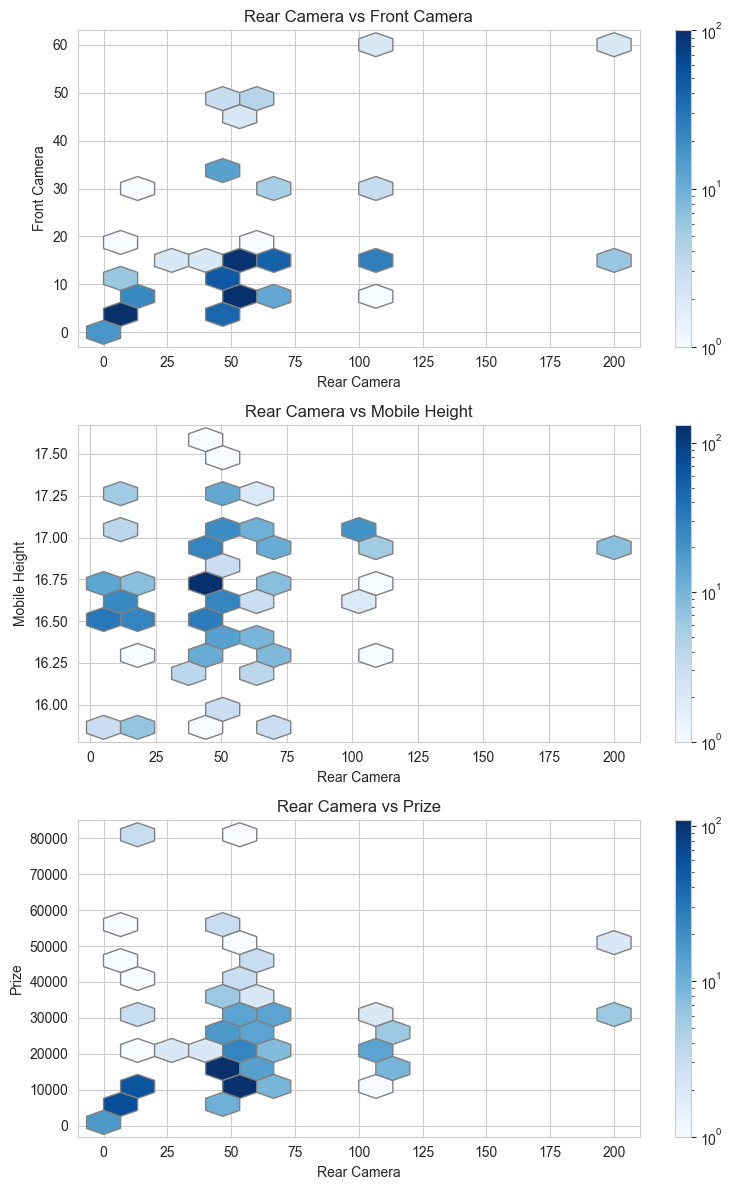

In [69]:
cols = ["Front Camera", "Mobile Height", "Prize"]

fig, axes = plt.subplots(len(cols), 1, figsize=(8, 12))

for i, col in enumerate(cols):
    hb = axes[i].hexbin(df["Rear Camera"], df[col],
                        gridsize=15,
                        cmap="Blues",
                        bins='log',
                        mincnt=1,
                        edgecolors='grey')
    
    axes[i].set_title(f"Rear Camera vs {col}")
    axes[i].set_xlabel("Rear Camera")
    axes[i].set_ylabel(col)
    
    fig.colorbar(hb, ax=axes[i])

plt.tight_layout()
plt.show()

## Rear Camera vs Front Camera  
- **Strongest density**: Rear cameras ~48–64 MP with front cameras ~16 MP → mainstream balance.  
- **Weaker density**: Ultra‑high rear cameras (108–200 MP) with modest front cameras (~10–16 MP) → premium devices prioritizing rear optics over selfies.

## Rear Camera vs Mobile Height
- **Strongest density**: Rear cameras ~48–64 MP with heights ~16.5–17.0 cm → standard smartphone dimensions.  
- **Weaker density**: Tall phones (>17.5 cm) with high rear cameras → niche phablets.

## 📊 Rear Camera vs Prize
- **Strongest density**: Rear cameras ~48–64 MP with prices ₹15k–₹30k → mainstream affordability cluster.  
- **Weaker density**: Ultra‑high rear cameras (108–200 MP) with prices >₹60k → premium flagships.
 
> **Mainstream density hotspots** cluster around 48–64 MP rear cameras, 16 MP front cameras, mid‑range prices, and standard dimensions.  
>**Weaker density regions** highlight premium strategies: ultra‑high rear cameras paired with high prices, sometimes decoupled from front camera specs or physical size.  
>**Interpretation**: Rear camera strength is tightly linked to pricing and partially to front camera quality, but independent of device size. It acts as a **key tier marker**, signaling premium positioning when specs exceed the mainstream density cluster.

### Rear Camera Vs Categorical Columns

In [70]:
df["RearCam_Group"] = pd.cut(df["Rear Camera"],
                            bins=[0, 8, 16, 32, 64, 108, 200],
                            labels=["<=8MP", "8-16MP", "16-32MP",
                                    "32-64MP", "64-108MP", "108MP+"])

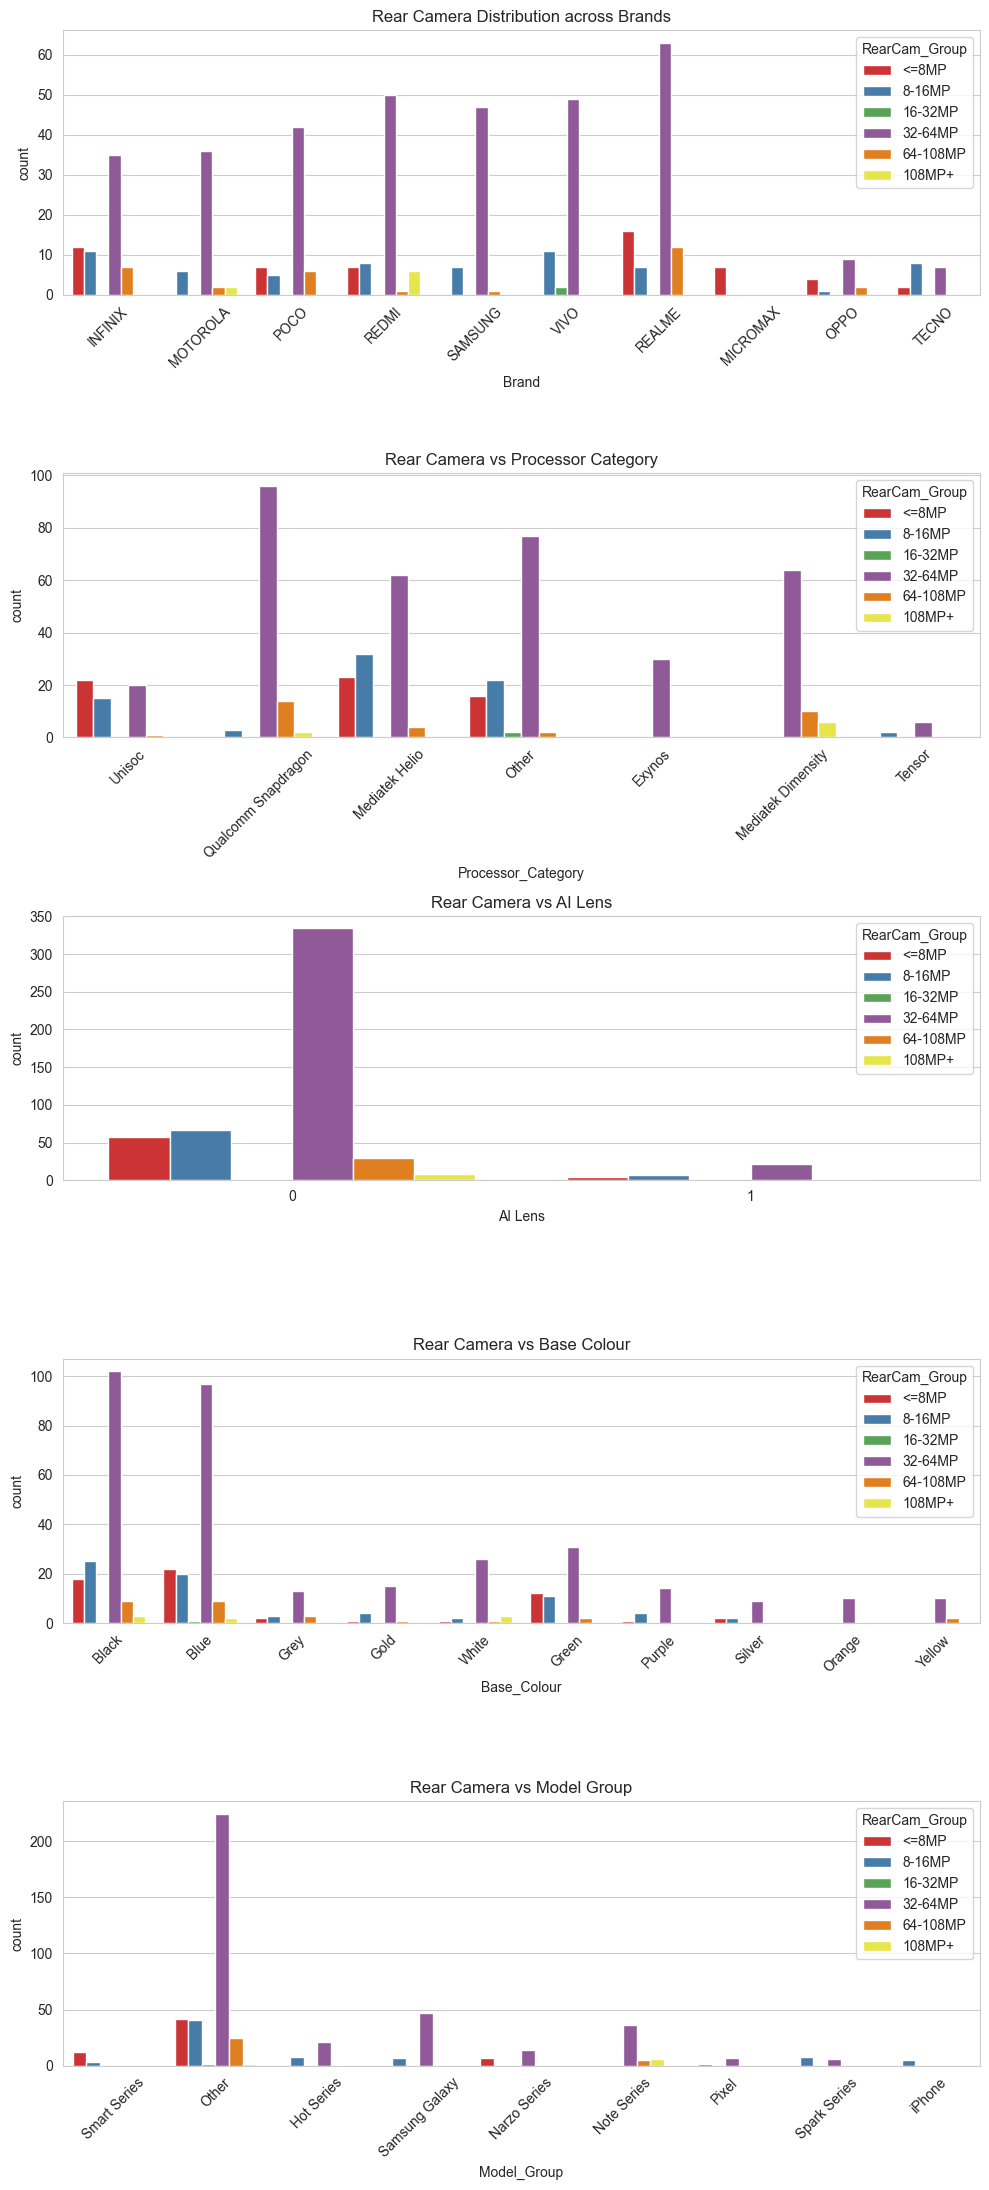

In [71]:
sns.set_style("whitegrid")

# Filter top categories
top_colors = df["Base_Colour"].value_counts().head(10).index
df_color = df[df["Base_Colour"].isin(top_colors)]

top_brands = df["Brand"].value_counts().head(10).index
df_brand = df[df["Brand"].isin(top_brands)]

# Create subplots
fig, axes = plt.subplots(5, 1, figsize=(10, 22))

# 1. Rear Camera vs Brand
sns.countplot(x="Brand", hue="RearCam_Group", data=df_brand,
              palette="Set1", ax=axes[0])
axes[0].set_title("Rear Camera Distribution across Brands")
axes[0].tick_params(axis='x', rotation=45)

# 2. Rear Camera vs Processor Category
sns.countplot(x="Processor_Category", hue="RearCam_Group", data=df,
              palette="Set1", ax=axes[1])
axes[1].set_title("Rear Camera vs Processor Category")
axes[1].tick_params(axis='x', rotation=45)

# 3. Rear Camera vs AI Lens
sns.countplot(x="AI Lens", hue="RearCam_Group", data=df,
              palette="Set1", ax=axes[2])
axes[2].set_title("Rear Camera vs AI Lens")

# 4. Rear Camera vs Base Colour
sns.countplot(x="Base_Colour", hue="RearCam_Group", data=df_color,
              palette="Set1", ax=axes[3])
axes[3].set_title("Rear Camera vs Base Colour")
axes[3].tick_params(axis='x', rotation=45)

# 5. Rear Camera vs Model Group
sns.countplot(x="Model_Group", hue="RearCam_Group", data=df,
              palette="Set1", ax=axes[4])
axes[4].set_title("Rear Camera vs Model Group")
axes[4].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 1. Rear Camera vs Brand
* **32–64MP dominates across almost all brands**. This is the **industry standard camera segment**
* **32–64MP** present mainly in **Realme, Redmi, Vivo, Samsung**.
* **64–108MP** Present mainly in **Realme, Poco, Samsung**
* **108MP+**: Very rare → only a few brands/models
* **Budget brands (Micromax, Tecno)**: More presence in **≤8MP and 8–16MP**

# 2. Rear Camera vs Processor
* **Snapdragon & Dimensity**
  * Strong presence in:
    * **32–64MP (dominant)**
    * **64–108MP & 108MP+**
* **Mediatek Helio**
  * Mostly **32–64MP**
  * Very limited high-end camera support
* **Unisoc**
  * Concentrated in **≤16MP**
* **Exynos / Tensor**
  * Mostly mid-to-high range (32–64MP)


# 3. Rear Camera vs AI Lens
* AI Lens = 1 phones are **very few**
* Most phones (with or without AI):

  * Still concentrated in **32–64MP**
* No major shift toward higher MP in AI-enabled phones

# 4. Rear Camera vs Base Colour

* Across all colours → **32–64MP dominates** Black & Blue:
  * Highest counts (due to overall popularity)
* No colour shows preference for high-end cameras

# 5. Rear Camera vs Model Group

* “Other” category:

  * Huge concentration in **32–64MP**
* Series models (Galaxy, Note, Narzo):

  * Mostly **mid-range (32–64MP)**
  * Some **64–108MP in premium series**
* Very limited **108MP+ models**

> The analysis indicates that rear camera specifications serve as a key differentiator in the smartphone market. While most devices cluster within the 32–64MP range, representing the industry standard, higher megapixel configurations (64–108MP and above) are selectively used by brands to position premium devices. A strong relationship is observed between processor capability and camera performance, with advanced chipsets such as Snapdragon and Dimensity supporting higher-end camera features. In contrast, factors like colour and AI Lens show minimal influence on camera specifications, highlighting that camera quality is primarily driven by hardware capability and brand positioning.*

## 5. Front Camera

### Front Camera Vs Numerical Coulmns

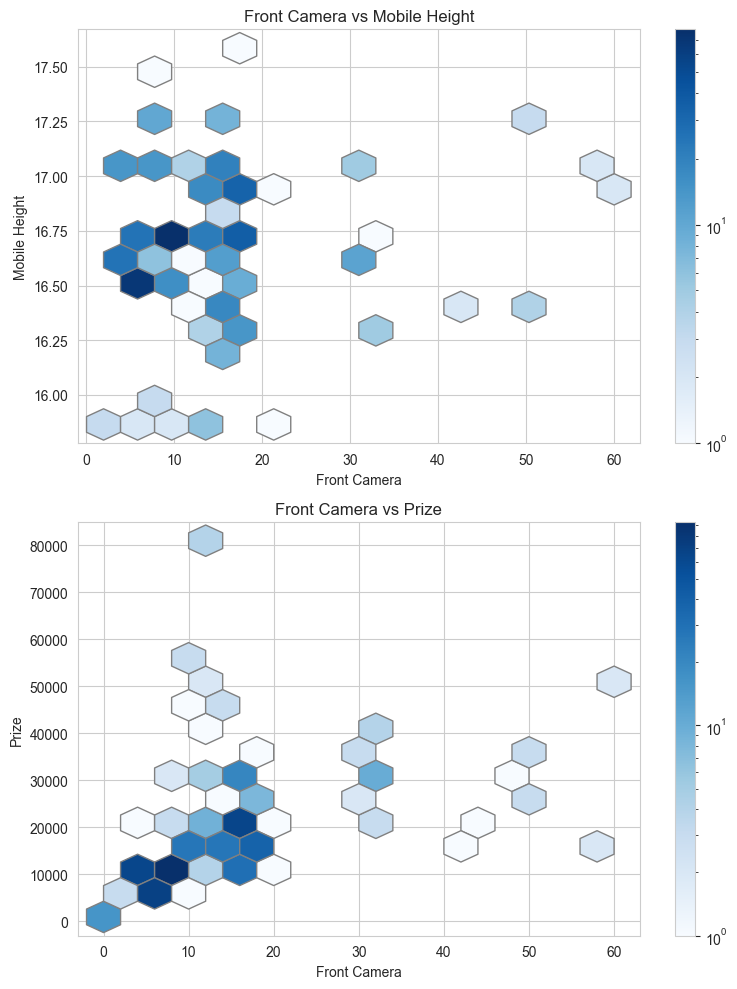

In [72]:
cols = ["Mobile Height", "Prize"]

fig, axes = plt.subplots(len(cols), 1, figsize=(8, 10))

for i, col in enumerate(cols):
    hb = axes[i].hexbin(df["Front Camera"], df[col],
                        gridsize=15,
                        cmap="Blues",
                        bins='log',
                        mincnt=1,
                        edgecolors='grey')
    
    axes[i].set_title(f"Front Camera vs {col}")
    axes[i].set_xlabel("Front Camera")
    axes[i].set_ylabel(col)
    
    fig.colorbar(hb, ax=axes[i])

plt.tight_layout()
plt.show()

## Front Camera vs Mobile Height
- **Strongest density**: Front cameras ~16 MP with mobile heights ~16.5–17.0 cm → mainstream cluster.  
- **Weaker density**: High front cameras (>32 MP) with taller phones (>17.5 cm) → rare phablet/selfie‑centric devices.

## Front Camera vs Prize
- **Strongest density**: Front cameras ~16 MP with prices ₹10k–₹30k → mainstream affordability cluster.  
- **Weaker density**: High front cameras (>32 MP) with premium prices (>₹50k) → niche flagships targeting selfie quality.

>Front camera resolution is **not a strong tier marker** compared to rear cameras, memory, or RAM.  
>**Mainstream density hotspots**: ~16 MP front cameras, mid‑range prices, and standard dimensions — the market’s center of gravity.  
>**Weaker density regions**: High‑resolution front cameras (>32 MP) appear in premium devices or larger form factors, but these are niche strategies rather than mass‑market norms.  

### Front Camera Vs Categorical Columns

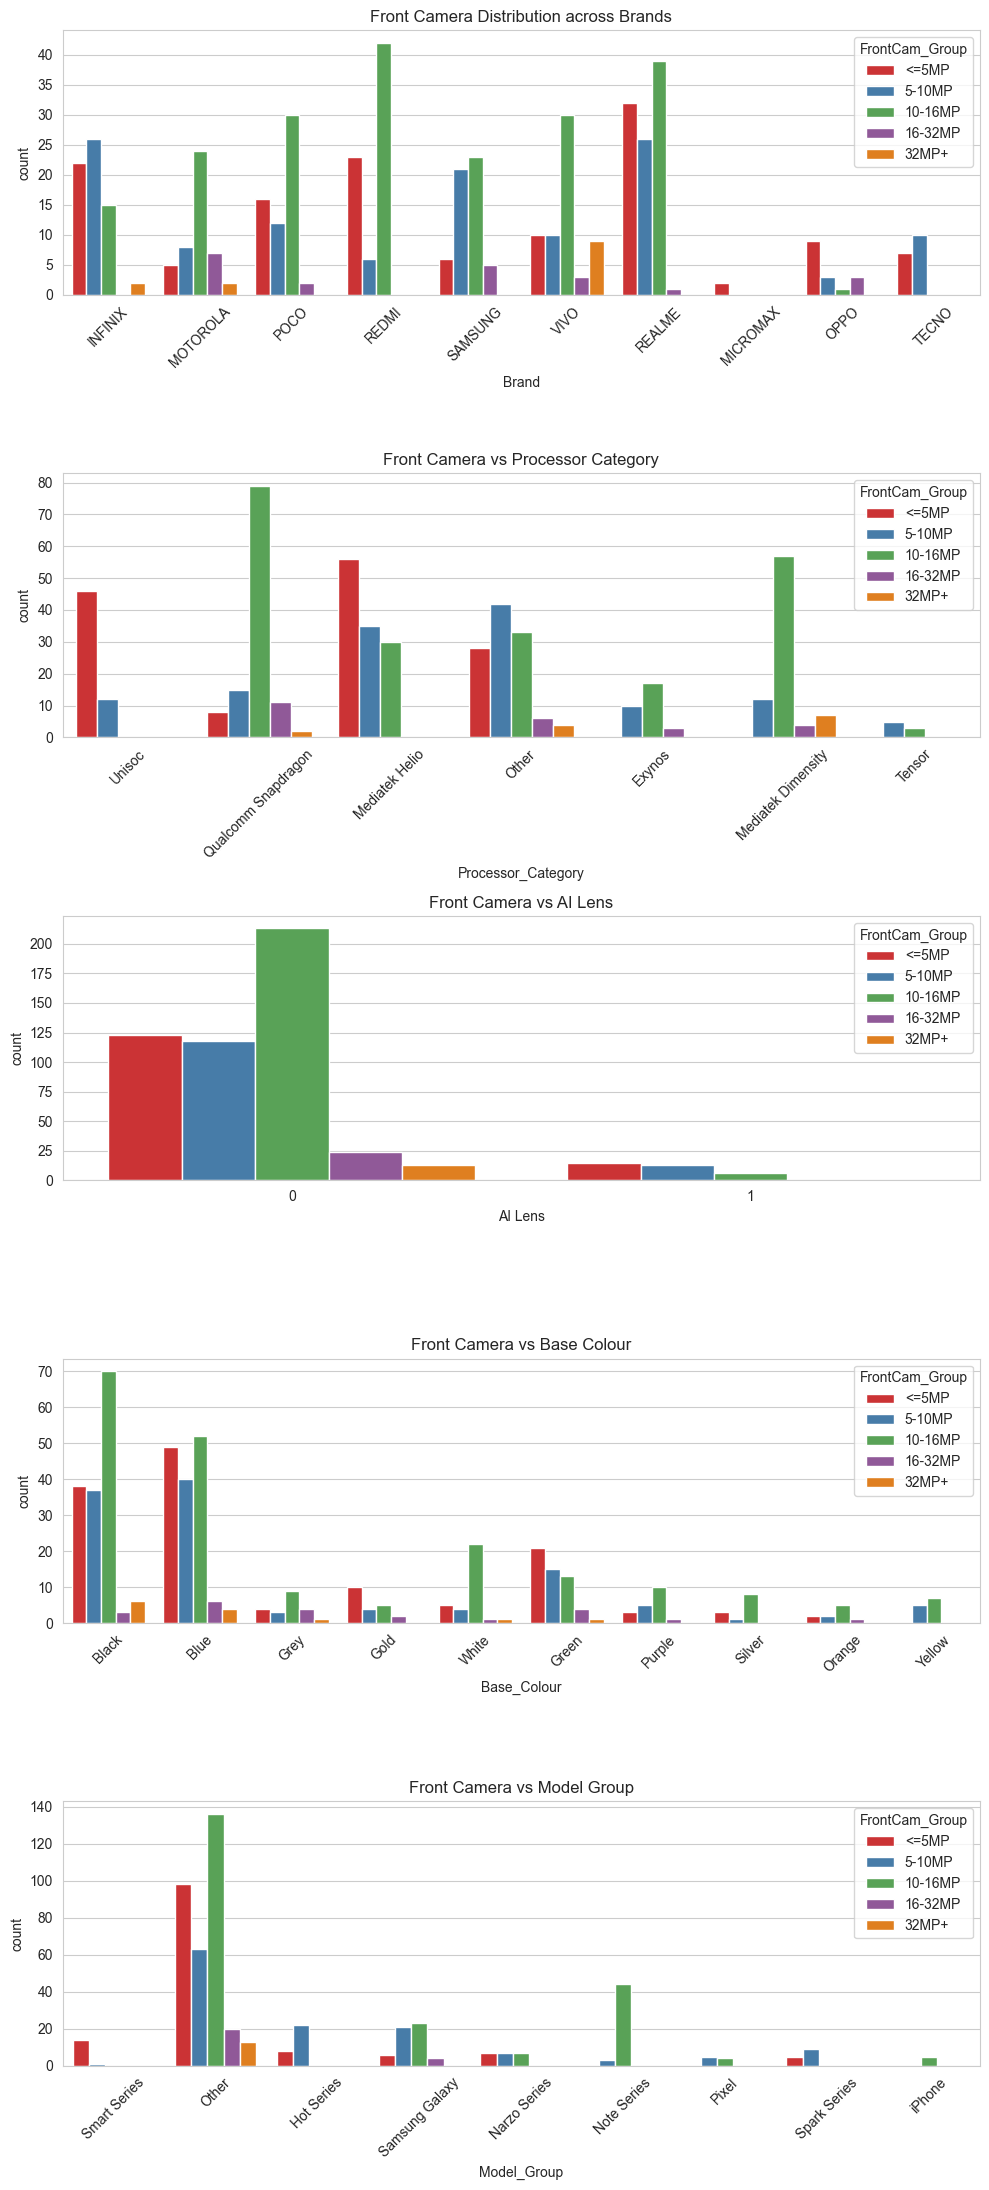

In [73]:
df["FrontCam_Group"] = pd.cut(df["Front Camera"],
                             bins=[0, 5, 10, 16, 32, 64],
                             labels=["<=5MP", "5-10MP", "10-16MP",
                                     "16-32MP", "32MP+"])


sns.set_style("whitegrid")

# Filter top categories
top_colors = df["Base_Colour"].value_counts().head(10).index
df_color = df[df["Base_Colour"].isin(top_colors)]

top_brands = df["Brand"].value_counts().head(10).index
df_brand = df[df["Brand"].isin(top_brands)]

# Create subplots
fig, axes = plt.subplots(5, 1, figsize=(10, 22))

# 1. Front Camera vs Brand
sns.countplot(x="Brand", hue="FrontCam_Group", data=df_brand,
              palette="Set1", ax=axes[0])
axes[0].set_title("Front Camera Distribution across Brands")
axes[0].tick_params(axis='x', rotation=45)

# 2. Front Camera vs Processor Category
sns.countplot(x="Processor_Category", hue="FrontCam_Group", data=df,
              palette="Set1", ax=axes[1])
axes[1].set_title("Front Camera vs Processor Category")
axes[1].tick_params(axis='x', rotation=45)

# 3. Front Camera vs AI Lens
sns.countplot(x="AI Lens", hue="FrontCam_Group", data=df,
              palette="Set1", ax=axes[2])
axes[2].set_title("Front Camera vs AI Lens")

# 4. Front Camera vs Base Colour
sns.countplot(x="Base_Colour", hue="FrontCam_Group", data=df_color,
              palette="Set1", ax=axes[3])
axes[3].set_title("Front Camera vs Base Colour")
axes[3].tick_params(axis='x', rotation=45)

# 5. Front Camera vs Model Group
sns.countplot(x="Model_Group", hue="FrontCam_Group", data=df,
              palette="Set1", ax=axes[4])
axes[4].set_title("Front Camera vs Model Group")
axes[4].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Front Camera Distribution across Brands
- **Mainstream density**: Most brands cluster around **10–16 MP and 16–32 MP front cameras**.  
- **Premium differentiation**: Vivo, Oppo, and Samsung show more devices in the **32MP+ category**, targeting selfie‑centric users.  
- **Budget tiers**: Infinix, Micromax, and Tecno lean toward ≤10 MP, reflecting entry‑level positioning.

## Front Camera vs Processor Category
- **Qualcomm Snapdragon & Dimensity**: More devices in **16–32 MP and 32MP+ ranges**, aligning with premium performance tiers.  
- **Helio & Unisoc**: Concentrated in **≤10 MP and 10–16 MP**, consistent with budget/mid‑range devices.  
- **Exynos & Tensor**: Appear in higher MP bins, reflecting flagship positioning (Samsung Galaxy, Google Pixel).

## Front Camera vs AI Lens
- **With AI lens**: Strong skew toward **16–32 MP and 32MP+**, showing AI features bundled with higher selfie specs.  
- **Without AI lens**: Concentrated in **≤10 MP and 10–16 MP**, typical of budget devices.

## Front Camera vs Base Colour
- **Neutral colours (Black, Blue, Grey, White)**: Broad distribution across all MP ranges, reflecting mainstream appeal.  
- **Premium colours (Gold, Silver, Purple)**: More devices in **32MP+**, signaling flagship differentiation.  
- **Niche colours (Green, Orange, Yellow)**: Sparse, mostly mid‑range front cameras.

## Front Camera vs Model Group
- **Mainstream series (Redmi Note, Realme Narzo, Samsung Galaxy)**: Concentrated in **16–32 MP**.  
- **Premium series (Pixel, iPhone)**: More devices in **32MP+**, emphasizing selfie quality.  
- **Budget series (Infinix Smart, Hot, Spark)**: Clustered in **≤10 MP and 10–16 MP**.

>**Interpretation**: The front camera is leveraged as a **branding and segmentation tool** — stabilizing the mainstream cluster while signaling premium identity through higher MP, AI features, and flagship aesthetics.

## 6. Prize

### Prize vs numerical columns(Mobile Height)

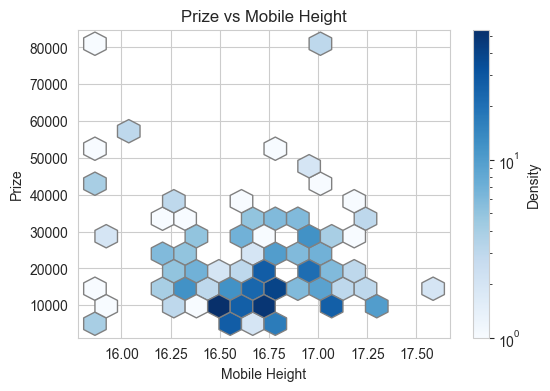

In [74]:
plt.figure(figsize=(6,4))

hb = plt.hexbin(df["Mobile Height"], df["Prize"],
                gridsize=15,
                cmap="Blues",
                bins='log',
                mincnt=1,
                edgecolors='grey')

plt.colorbar(hb, label='Density')
plt.title("Prize vs Mobile Height")
plt.xlabel("Mobile Height")
plt.ylabel("Prize")

plt.show()

## Prize Vs Mobile Height
- **Correlation**: Very weak — mobile height does not strongly influence price.  
- **Strongest density**:  
  - Phones with **heights ~16.5–17.0 cm** priced in the **₹10k–₹30k range** → mainstream cluster.  
- **Weaker density**:  
  - Taller phones (>17.5 cm) with premium prices (>₹50k) → niche phablets and flagships.  
  - Compact phones (<16.2 cm) with varied prices → rare, less consistent.


>Mobile height is **not a tier-defining feature**. 
>Price is driven more by specs like RAM, storage, and cameras, while height reflects ergonomic norms. Manufacturers rarely use physical size as a differentiator, except in specialized segments.

### Prize Vs Categorical columns

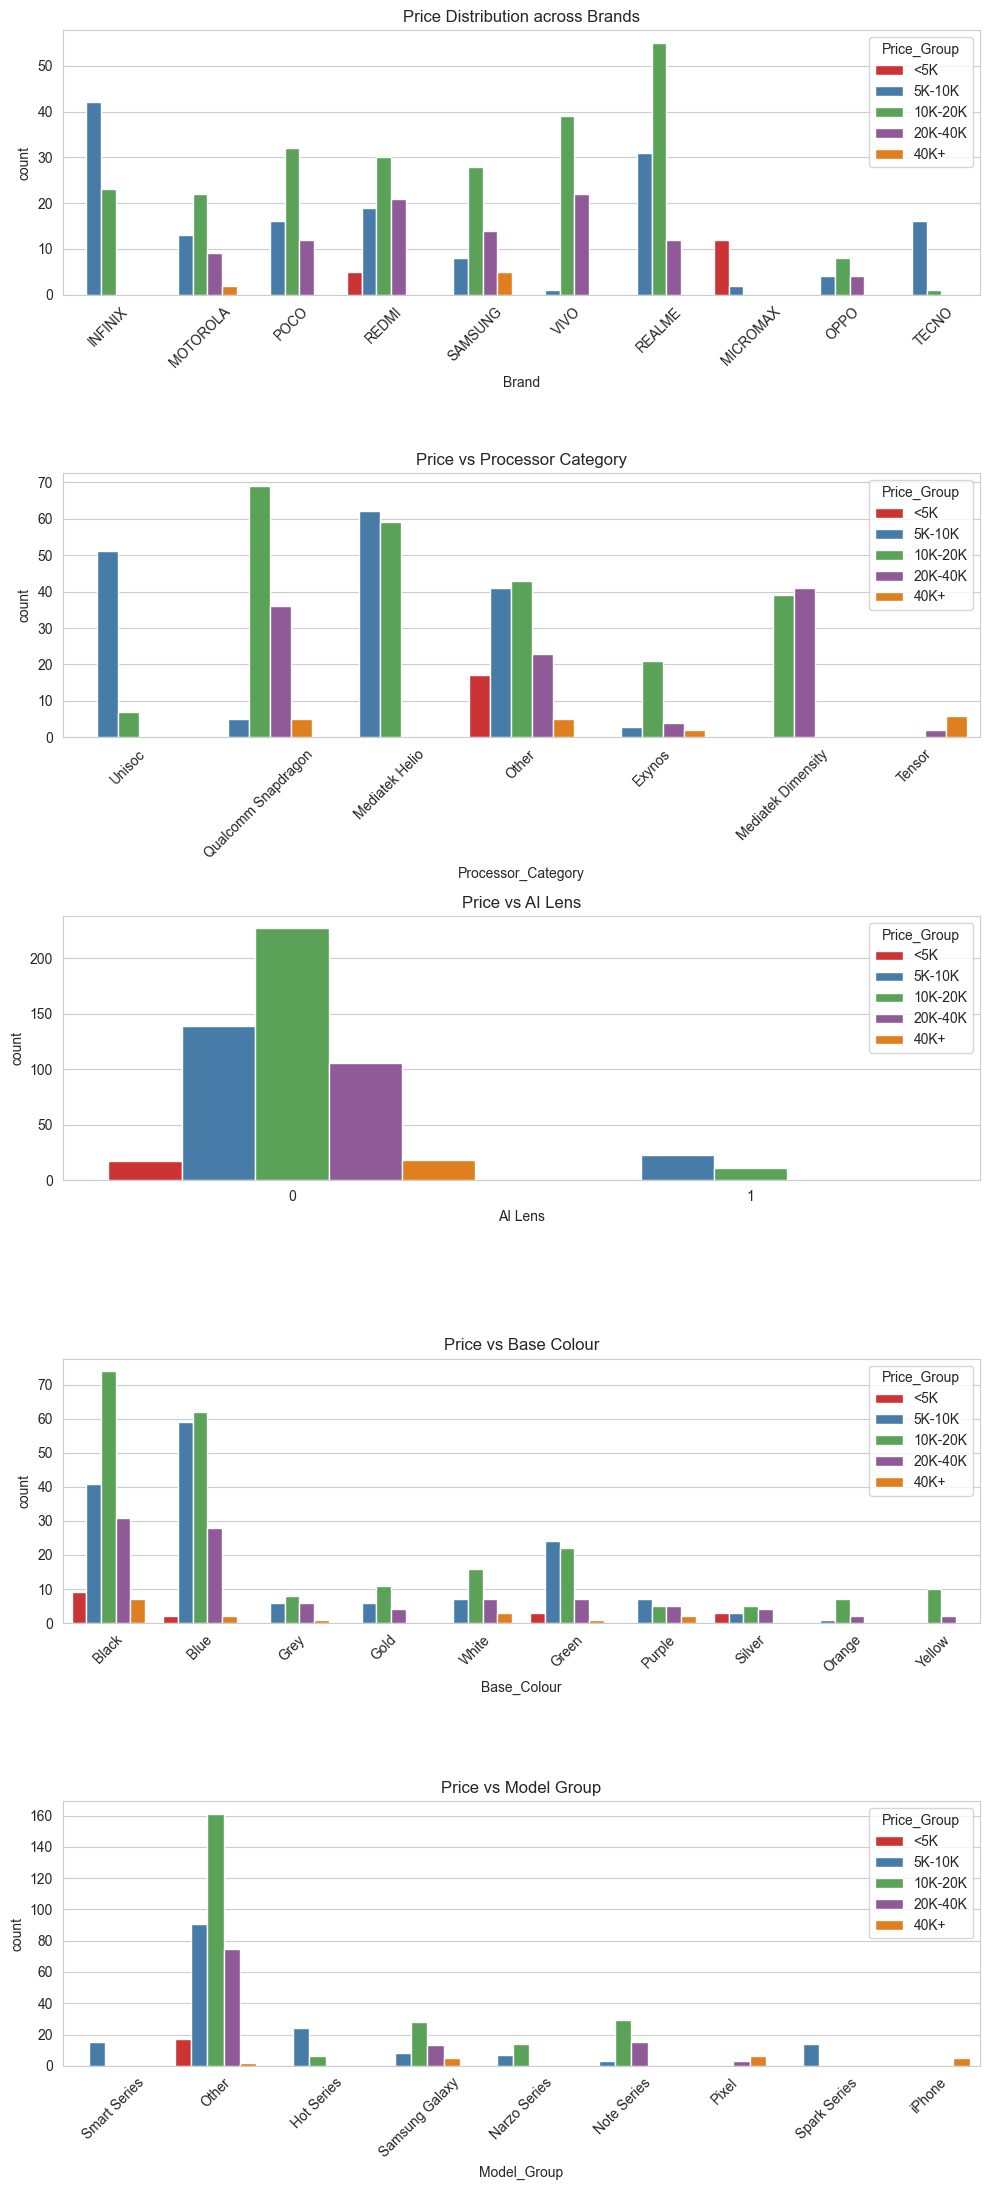

In [75]:
df["Price_Group"] = pd.cut(df["Prize"],
                          bins=[0, 5000, 10000, 20000, 40000, 100000],
                          labels=["<5K", "5K-10K", "10K-20K",
                                  "20K-40K", "40K+"])


sns.set_style("whitegrid")

# Filter top categories
top_colors = df["Base_Colour"].value_counts().head(10).index
df_color = df[df["Base_Colour"].isin(top_colors)]

top_brands = df["Brand"].value_counts().head(10).index
df_brand = df[df["Brand"].isin(top_brands)]

# Create subplots
fig, axes = plt.subplots(5, 1, figsize=(10, 22))

# 1. Price vs Brand
sns.countplot(x="Brand", hue="Price_Group", data=df_brand,
              palette="Set1", ax=axes[0])
axes[0].set_title("Price Distribution across Brands")
axes[0].tick_params(axis='x', rotation=45)

# 2. Price vs Processor Category
sns.countplot(x="Processor_Category", hue="Price_Group", data=df,
              palette="Set1", ax=axes[1])
axes[1].set_title("Price vs Processor Category")
axes[1].tick_params(axis='x', rotation=45)

# 3. Price vs AI Lens
sns.countplot(x="AI Lens", hue="Price_Group", data=df,
              palette="Set1", ax=axes[2])
axes[2].set_title("Price vs AI Lens")

# 4. Price vs Base Colour
sns.countplot(x="Base_Colour", hue="Price_Group", data=df_color,
              palette="Set1", ax=axes[3])
axes[3].set_title("Price vs Base Colour")
axes[3].tick_params(axis='x', rotation=45)

# 5. Price vs Model Group
sns.countplot(x="Model_Group", hue="Price_Group", data=df,
              palette="Set1", ax=axes[4])
axes[4].set_title("Price vs Model Group")
axes[4].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Price Distribution across Brands
- **Mainstream density**: Redmi and Realme dominate the **₹10k–₹20k range**, reflecting their mid‑market focus.  
- **Premium differentiation**: Samsung, Vivo, and Oppo show stronger presence in the **₹40k+ segment**, signaling flagship positioning.  
- **Budget tiers**: Infinix, Tecno, and Micromax cluster in the **<₹10k range**, targeting entry‑level buyers.

## Price vs Processor Category
- **Snapdragon & Dimensity**: Concentrated in **₹10k–₹40k and ₹40k+**, aligning with mid‑range and premium devices.  
- **Helio & Unisoc**: Dominant in **<₹10k–₹20k**, consistent with budget/mid‑range phones.  
- **Exynos & Tensor**: Appear mostly in **₹40k+**, tied to Samsung Galaxy and Google Pixel flagships.

## Price vs AI Lens
- **Without AI lens**: Clustered in **₹5k–₹20k**, typical of budget/mid‑range phones.  
- **With AI lens**: More spread into **₹20k–₹40k and ₹40k+**, showing AI features bundled with higher‑tier devices.

## Price vs Base Colour
- **Neutral colours (Black, Blue, Grey, White)**: Broad distribution, but densest in **₹10k–₹20k**, reflecting mainstream appeal.  
- **Premium colours (Gold, Silver, Purple)**: Skew toward **₹40k+**, signaling flagship differentiation.  
- **Niche colours (Green, Orange, Yellow)**: Sparse, mostly budget/mid‑range.

## Price vs Model Group
- **Mainstream series (Redmi Note, Realme Narzo, Samsung Galaxy)**: Concentrated in **₹10k–₹20k**.  
- **Premium series (Pixel, iPhone)**: Dominant in **₹40k+**, reinforcing flagship tiering.  
- **Budget series (Infinix Smart, Hot, Spark)**: Clustered in **<₹10k–₹20k**, entry‑level positioning.

>Price distribution clearly reflects **tier segmentation across brands, processors, and series**:  
>**Mainstream density hotspots**: ₹10k–₹20k, dominated by Redmi and Realme, Snapdragon/Helio processors, neutral colours, and mid‑range series.  
>Price acts as the **ultimate tier anchor**, consolidating the patterns seen in memory, RAM, battery, and cameras. Mid‑range pricing defines the market’s center of gravity, while premium and budget segments differentiate through brand identity, processor choice, and design cues.

## 7. Mobile Height

### Mobile height vs Categorical columns

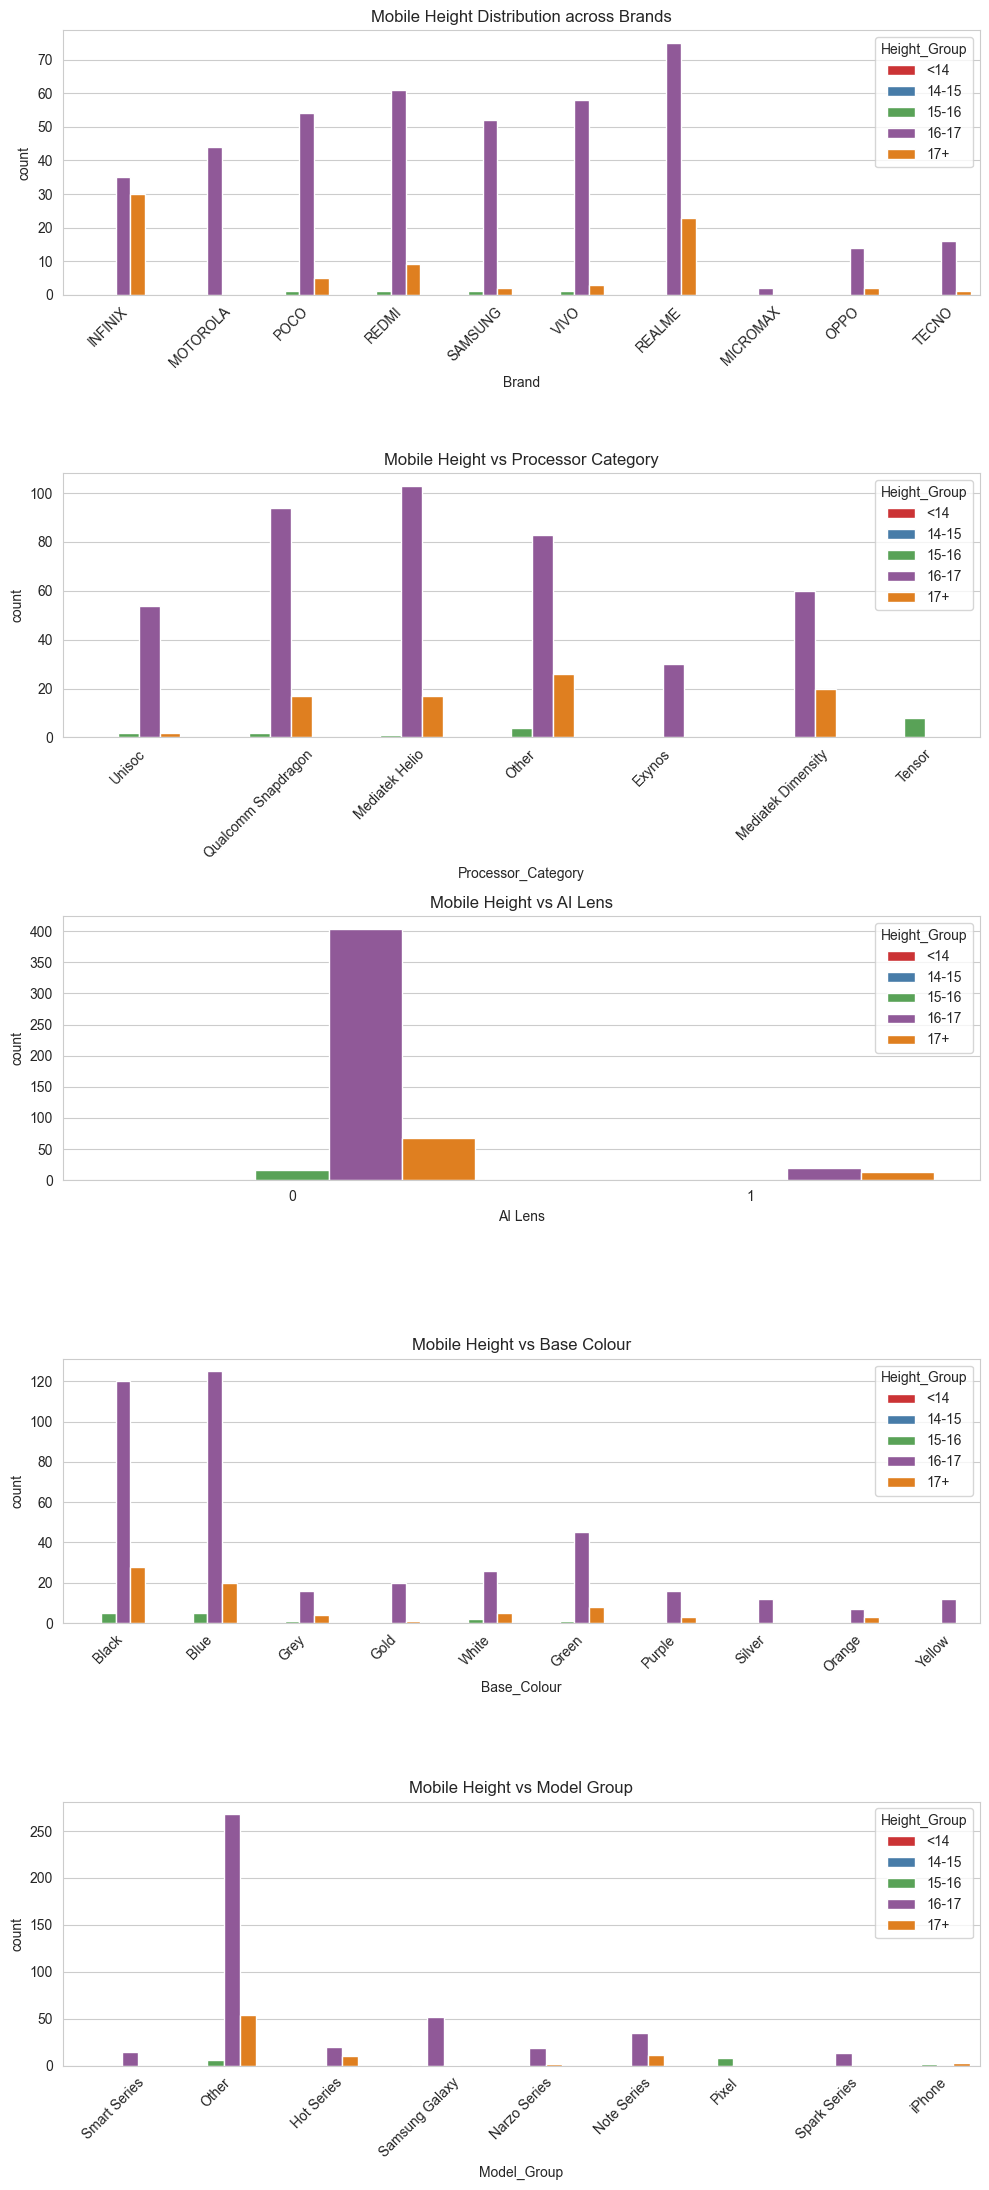

In [76]:
df["Height_Group"] = pd.cut(df["Mobile Height"],
                           bins=[0, 14, 15, 16, 17, 20],
                           labels=["<14", "14-15", "15-16",
                                   "16-17", "17+"])

sns.set_style("whitegrid")

# Filter top categories
top_colors = df["Base_Colour"].value_counts().head(10).index
df_color = df[df["Base_Colour"].isin(top_colors)]

top_brands = df["Brand"].value_counts().head(10).index
df_brand = df[df["Brand"].isin(top_brands)]

# Create subplots
fig, axes = plt.subplots(5, 1, figsize=(10, 22))

# 1. Height vs Brand
sns.countplot(x="Brand", hue="Height_Group", data=df_brand,
              palette="Set1", ax=axes[0])
axes[0].set_title("Mobile Height Distribution across Brands")
axes[0].tick_params(axis='x', rotation=45)

# 2. Height vs Processor Category
sns.countplot(x="Processor_Category", hue="Height_Group", data=df,
              palette="Set1", ax=axes[1])
axes[1].set_title("Mobile Height vs Processor Category")
axes[1].tick_params(axis='x', rotation=45)

# 3. Height vs AI Lens
sns.countplot(x="AI Lens", hue="Height_Group", data=df,
              palette="Set1", ax=axes[2])
axes[2].set_title("Mobile Height vs AI Lens")

# 4. Height vs Base Colour
sns.countplot(x="Base_Colour", hue="Height_Group", data=df_color,
              palette="Set1", ax=axes[3])
axes[3].set_title("Mobile Height vs Base Colour")
axes[3].tick_params(axis='x', rotation=45)

# 5. Height vs Model Group
sns.countplot(x="Model_Group", hue="Height_Group", data=df,
              palette="Set1", ax=axes[4])
axes[4].set_title("Mobile Height vs Model Group")
axes[4].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Mobile Height Distribution across Brands
- **Mainstream density**: The **16–17** group dominates across nearly all brands**, showing a strong industry standard.  
- **Outliers**: Few devices fall into <15  or >17, highlighting compact phones and phablets as niche categories.  
- **Brand differentiation**: Samsung, Vivo, and Oppo show slightly more representation in the >17  group, reflecting premium phablet designs.

## Mobile Height vs Processor Category
- **Consistency**: Across Unisoc, Snapdragon, Helio, Dimensity, Exynos, and Tensor, the **16–17 group is dominant**, confirming size independence from processor choice.  
- **Premium processors (Exynos, Tensor)**: Slight skew toward taller phones (>17 cm), tied to flagship models.

## Mobile Height vs AI Lens
- **Without AI lens**: Much higher counts, especially in the **16–17 group**, showing mainstream devices without advanced AI features.  
- **With AI lens**: Fewer devices overall, but spread across standard heights, suggesting AI features are not tied to size.

## Mobile Height vs Base Colour
- **Neutral colours (Black, Blue)**: Highest counts, concentrated in **16–17**, reflecting mainstream appeal.  
- **Premium colours (Gold, Silver, Purple)**: Appear more in taller phones (>17), signaling flagship differentiation.  
- **Niche colours (Green, Orange, Yellow)**: Sparse, mostly mid‑range heights.

## Mobile Height vs Model Group
- **Mainstream series (Redmi Note, Realme Narzo, Samsung Galaxy)**: Dominated by **16–17 phones**, reinforcing ergonomic norms.  
- **Premium series (Pixel, iPhone)**: Slightly more representation in taller phones (>17).  
- **Budget series (Smart, Hot, Spark)**: Clustered in **16–17**, showing even entry‑level devices conform to standard dimensions.

>Mobile height is a **stabilizing design feature**
>**Interpretation**: Unlike memory, RAM, or cameras, mobile height is not a tier marker but a **design constant**, anchoring most devices in the same ergonomic range. Outliers in taller or compact categories serve as differentiation points for premium or niche segments.

## 8. Brand

### Brand vs Base colour

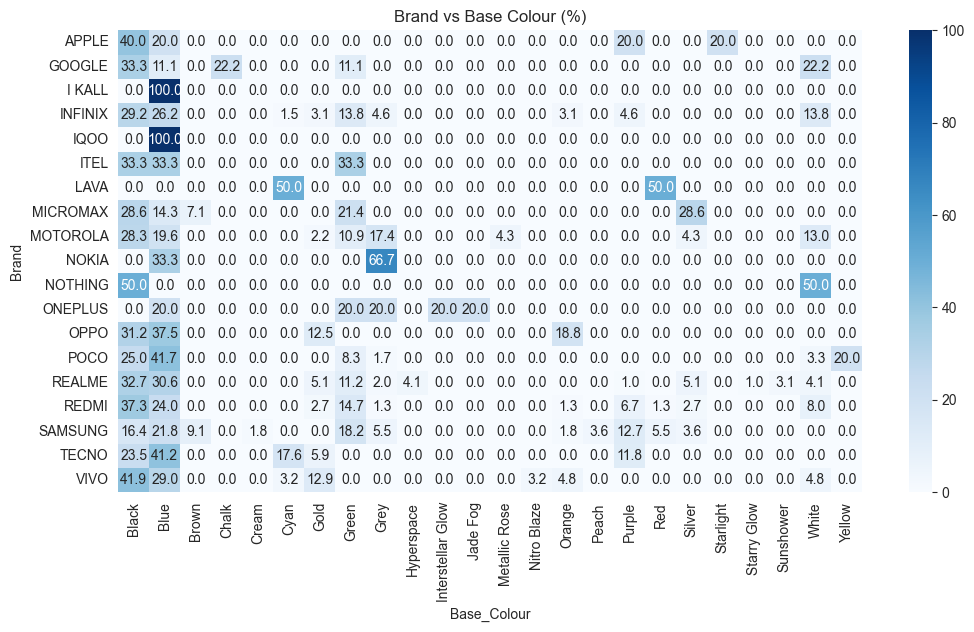

In [77]:
col = "Base_Colour"

ct = pd.crosstab(df["Brand"], df[col], normalize="index") * 100

plt.figure(figsize=(12,6))
sns.heatmap(ct, annot=True, cmap="Blues", fmt=".1f")
plt.title("Brand vs Base Colour (%)")
plt.show()

## Colour Preferences by Brand
- **Single‑colour dominance**:  
  - Some brands lock into one colour identity:  
    - **I KALL, IQOO, Infinix** → 100% Blue.  
    - **Nokia** → 66.7% Grey.  
    - **Nothing** → split evenly (50% Black, 50% White), reflecting minimalist branding.  
- **Mainstream brands (Samsung, Redmi, Realme, Oppo, Vivo)**:  
  - Broad distribution across **Black, Blue, Grey, and White**, showing mass‑market appeal.  
  - Occasional premium shades (Gold, Silver, Purple) appear in flagships.

## Premium Differentiation
- **Apple**: Strong presence in **Starlight, Silver, and unique shades** (Metallic Rose, Hyperspace), signaling luxury positioning.  
- **Google**: Distinctive palette (Chalk, Jade Fog, Peach), reinforcing playful design identity.  
- **OnePlus**: Mix of **Black, Silver, and niche shades** (Interstellar Glow, Nitro Blaze), balancing mainstream and premium aesthetics.

## Niche Colours
- **Orange, Yellow, Sunflower, Cyan**: Rare, tied to specific models or limited editions.  
- These colours act as **novelty differentiators**, not mainstream anchors.
 
>**Mainstream density hotspots**: Black, Blue, Grey, White → universal appeal across mid‑range devices.  
>**Premium strategies**: Unique shades (Starlight, Jade Fog, Metallic Rose) → used by Apple, Google, and OnePlus to signal exclusivity.  
>**Budget positioning**: Brands like Infinix, I KALL, Tecno → rely on single‑colour dominance (Blue, Grey) to simplify production and appeal to entry‑level buyers.  

>**Interpretation**: Base colour is less about technical tiering (like RAM or cameras) and more about **brand storytelling**. Neutral colours stabilize the mainstream cluster, while distinctive palettes differentiate premium identity.

### Brand vs AI Lense

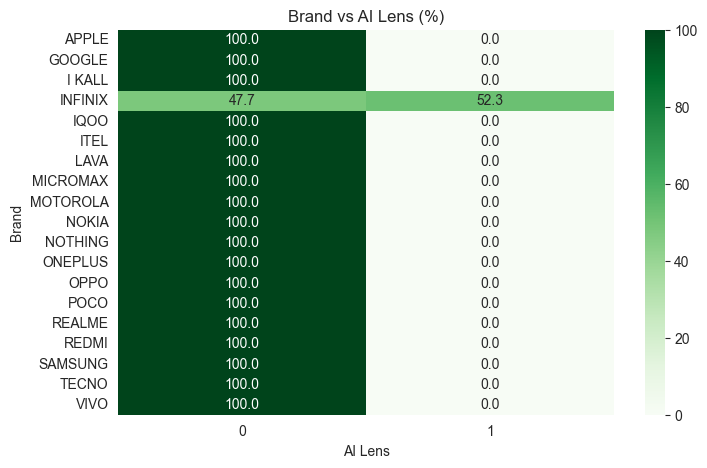

In [78]:
col = "AI Lens"

ct = pd.crosstab(df["Brand"], df[col], normalize="index") * 100

plt.figure(figsize=(8,5))
sns.heatmap(ct, annot=True, cmap="Greens", fmt=".1f")
plt.title("Brand vs AI Lens (%)")
plt.show()

## Brand Vs AI Lense
- **Single‑brand adoption**:  
  - **Infinix** is the **only brand** showing a split: ~52% of its devices include an AI lens, while ~48% do not.  
- **All other brands**: Apple, Google, Samsung, Vivo, Oppo, Redmi, Realme, Motorola, etc. → **100% without AI lens**.  
- This indicates that AI lens integration is **not yet an industry‑wide standard**, but rather an experimental feature concentrated in one brand.

>AI lens technology is currently **brand‑specific rather than market‑wide**. 
> lens adoption is still in its infancy. Instead of being a tier marker like RAM, storage, or rear camera resolution, it serves as a **brand‑level experiment**. Infinix uses it to stand out, while larger brands rely on established camera hardware and software ecosystems.

### Brand vs Processor_

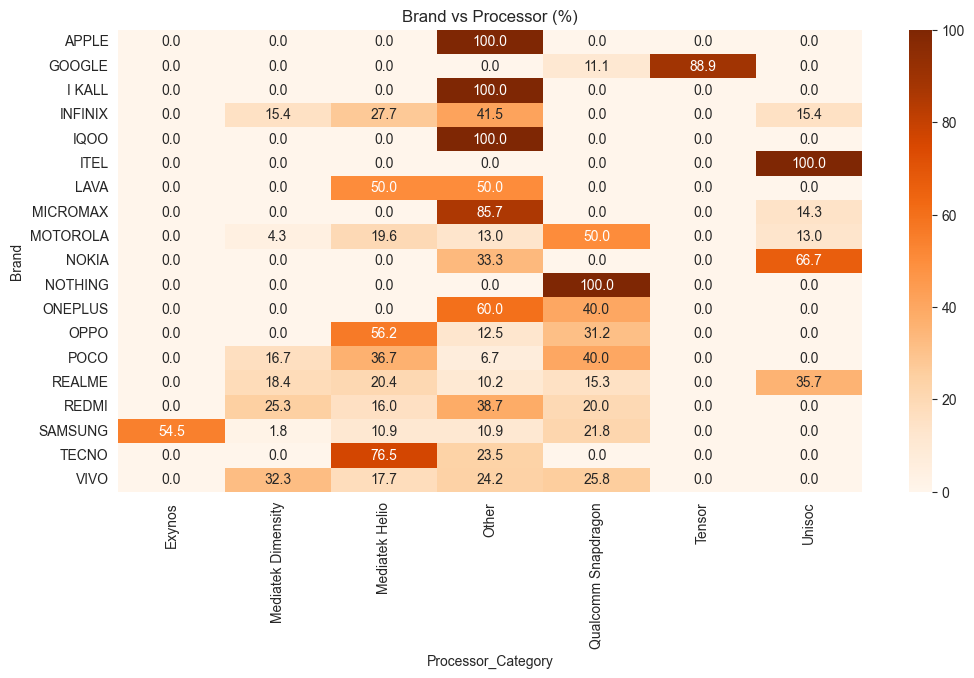

In [79]:
col = "Processor_Category"

ct = pd.crosstab(df["Brand"], df[col], normalize="index") * 100

plt.figure(figsize=(12,6))
sns.heatmap(ct, annot=True, cmap="Oranges", fmt=".1f")
plt.title("Brand vs Processor (%)")
plt.show()

## Processor Exclusivity
- **Apple**: 100% in “Other” → proprietary Apple silicon (A‑series, M‑series).  
- **Google**: ~89% Tensor → strong reliance on its in‑house processor line.  
- **Samsung**: ~55% Exynos, with the rest split across Snapdragon → dual‑strategy balancing in‑house and Qualcomm.  
- **I KALL**: 100% “Other” → non‑mainstream processors, reflecting budget positioning.

## Mid‑Range Dominance
- **Realme, Redmi, Oppo, Vivo, Tecno, Infinix**: Heavy reliance on **Mediatek Helio** and **Dimensity**, showing cost‑effective mid‑range focus.  
- **Tecno**: ~77% Helio → budget/mid‑range emphasis.  
- **Infinix**: Mix of Helio and Unisoc → entry‑level affordability.

## Premium Differentiation
- **OnePlus, IQOO, Poco, Motorola**: Strong reliance on **Snapdragon**, aligning with performance‑oriented positioning.  
- **Samsung Galaxy flagships**: Split between Exynos and Snapdragon, depending on region.  
- **Google Pixel**: Tensor exclusivity → brand identity tied to AI‑driven performance.

 >Processor distribution reflects both **brand identity and tier segmentation**. Mid‑range brands cluster around Mediatek for affordability, while premium players differentiate through proprietary or high‑performance chipsets.

### Brand vs Model_Group

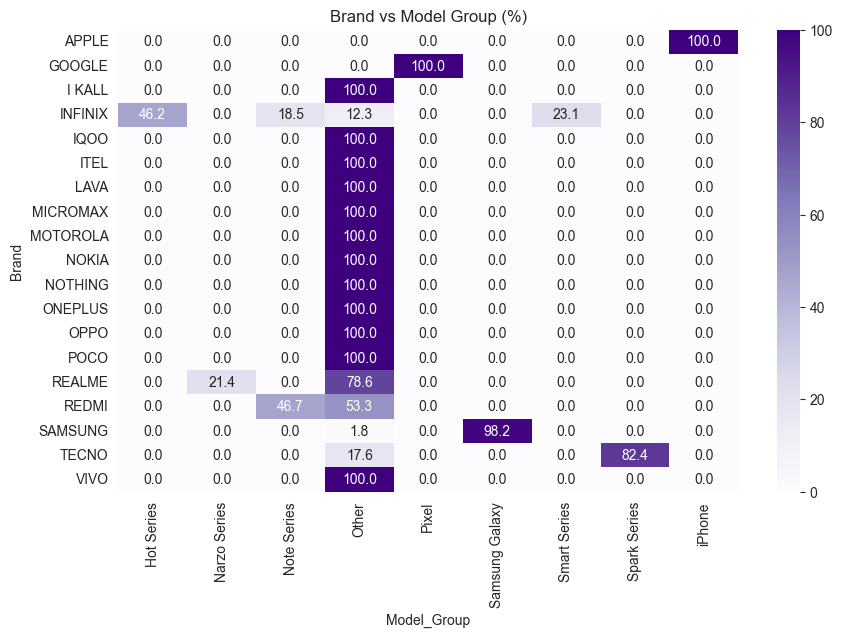

In [80]:
ct = pd.crosstab(df["Brand"], df["Model_Group"], normalize="index") * 100

plt.figure(figsize=(10,6))
sns.heatmap(ct, annot=True, cmap="Purples", fmt=".1f")
plt.title("Brand vs Model Group (%)")
plt.show()


## Brand Specialization
- **Exclusive identity brands**:  
  - **Apple → 100% iPhone**  
  - **Google → 100% Pixel**  
  - **Samsung → ~98% Galaxy**  
  These brands are tightly bound to their flagship model groups, reinforcing strong brand identity and consumer recognition.  

- **Diversified brands**:  
  - **Realme, Redmi, Oppo, Vivo, Motorola, Poco** → spread across multiple series (Narzo, Note, Smart, Spark, Hot, Other).  
  This shows broader segmentation strategies, targeting multiple tiers (budget, mid‑range, premium).

## Budget vs Premium Segmentation
- **Budget series**: Infinix (Smart, Hot, Spark), Tecno (Spark, Other), Micromax, Itel, Lava → concentrated in entry‑level model groups.  
- **Premium series**: Apple iPhone, Google Pixel, Samsung Galaxy → exclusive flagship positioning.  
- **Mid‑range series**: Redmi Note, Realme Narzo, Oppo and Vivo “Other” → balance between affordability and performance.

## Market Strategy
- **Single‑series dominance**: Apple, Google, Samsung → strong vertical integration, clear flagship branding.  
- **Multi‑series spread**: Chinese OEMs (Realme, Redmi, Oppo, Vivo, Infinix, Tecno) → horizontal segmentation, offering multiple product lines to capture diverse consumer bases.  
- **Niche brands**: Nothing, Nokia, Motorola → smaller distributions, reflecting limited but distinct positioning.


 
>**Flagship exclusivity** (Apple, Google, Samsung) → tightly bound to one iconic series, reinforcing premium identity.  
>**Multi‑series diversification** (Realme, Redmi, Oppo, Vivo, Infinix, Tecno) → spread across multiple groups to cover budget, mid‑range, and premium tiers.  
>Model groups act as a **structural tiering mechanism**. Flagship‑exclusive brands rely on strong identity and premium pricing, while diversified brands use multiple series to maximize reach across consumer segments.

## 9. AI Lense

### AI Lense and Processor_

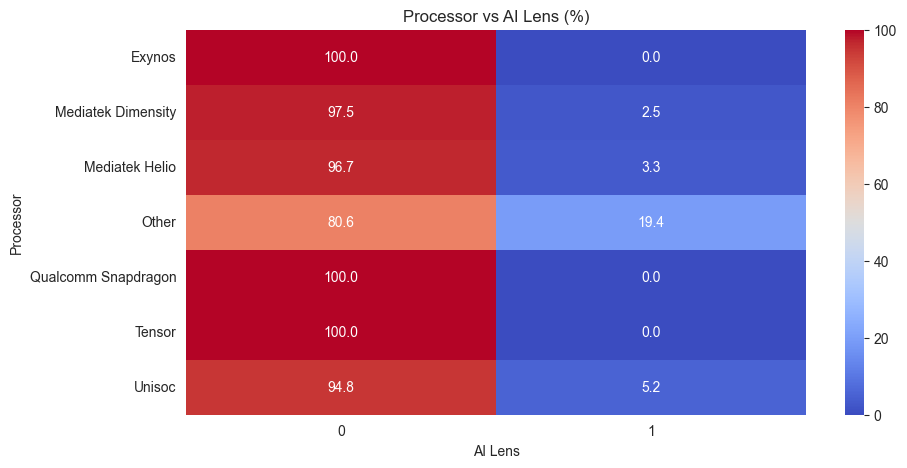

In [81]:
ct = pd.crosstab(df["Processor_Category"], df["AI Lens"], normalize="index") * 100

plt.figure(figsize=(10,5))
sns.heatmap(ct, annot=True, cmap="coolwarm", fmt=".1f")
plt.title("Processor vs AI Lens (%)")
plt.xlabel("AI Lens")
plt.ylabel("Processor")
plt.show()

## Processor_ Vs AI Lense
- **No AI Lens adoption**:  
  - **Exynos, Snapdragon, Tensor** → 100% of devices show **no AI lens integration**.  
  - This confirms that flagship processors from Samsung, Qualcomm, and Google are not tied to AI lens hardware.  

- **Minimal adoption in Mediatek**:  
  - **Dimensity** → ~2.5% with AI lens.  
  - **Helio** → ~3.3% with AI lens.  
  - Suggests limited experimentation in mid‑range devices.  

- **Moderate adoption in “Other” processors**:  
  - ~19% of devices with AI lens, showing some niche or proprietary chipsets experimenting with the feature.  

- **Unisoc**: ~5% adoption, reflecting entry‑level devices selectively adding AI lens. 

>AI lens is not yet a performance tier marker. Instead, it appears as a **budget/mid‑range feature experiment**, while premium devices emphasize proprietary algorithms and hardware rather than explicit AI lens branding.

## Multivariate Analysis

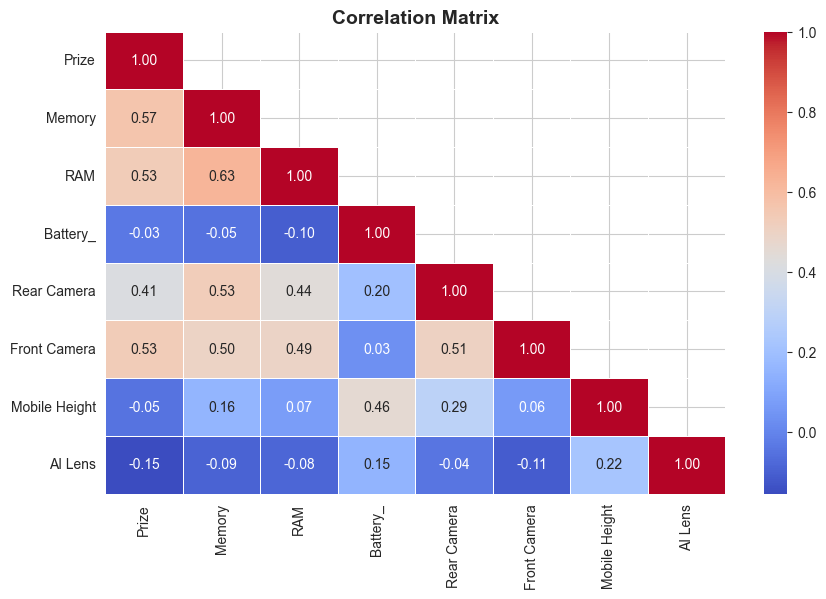

In [82]:
cols = ['Prize','Memory','RAM','Battery_','Rear Camera','Front Camera','Mobile Height','AI Lens']

corr = df[cols].corr()

# Mask ONLY upper triangle (not diagonal)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix", fontsize=14, fontweight="bold")
plt.show()

## Multivariate Analysis 

### **Strong / Positive Relationships**

- **Memory vs RAM (0.63)**: Higher RAM devices *tend* to come with higher storage.
- **Memory vs Prize (0.57)**: Storage is a key pricing factor. Higher storage variants are positioned as premium offerings.
- **RAM vs Prize (0.52)**: Devices with higher RAM are generally priced higher, reflecting their positioning as performance-oriented smartphones.

### **Weak / Negative Relationships**

- **Battery vs RAM (slightly negative)**: There is a weak negative relationship, suggesting that higher RAM does not necessarily translate to larger battery capacity.
- **Battery vs Other Features**: Battery capacity appears largely independent of pricing and camera specifications, suggesting it is standardized (e.g., 5000 trend) rather than a premium differentiator.
- **Mobile Height vs Prize**: Mobile height shows little to no correlation with price, indicating that physical dimensions are not a major pricing factor.

### **Moderate Relationships**

- **Rear Camera vs Front Camera (0.36)**: Moderate correlation suggests that devices with better rear cameras tend to also offer improved front cameras, likely due to overall positioning in mid/high-end segments.
- **Prize vs Rear Camera (0.41)**: Higher rear camera specifications moderately influence price, reflecting consumer preference for photography features.
- **Prize vs Front Camera (0.34)**: Front camera also impacts price, but less strongly than rear camera, indicating rear camera is a bigger selling point.

### **AI Lense**
- The AI Lens feature shows negligible correlation with all major variables, including price (-0.15), RAM (-0.08), memory (-0.09), and camera specifications. This indicates that AI Lens is not a key factor influencing device pricing or performance. The weak correlations suggest that it is likely a supplementary or marketing-driven feature rather than a core differentiator in smartphone specifications.

### **Conclusion**
> The correlation analysis reveals that Memory and RAM have a strong positive relationship (0.63), indicating that higher-performance devices are typically paired with larger storage capacities. Both Memory (0.57) and RAM (0.52) show strong correlations with price, confirming that performance and storage are key drivers of smartphone pricing.
>
> Battery capacity shows weak or negligible correlation with most features, suggesting it is relatively standardized across devices and not a primary factor influencing price. Similarly, mobile height has minimal impact on pricing, indicating that physical dimensions are not a differentiating factor.
>
> Moderate correlations exist between rear and front camera (0.36), as well as between price and camera specifications (rear: 0.41, front: 0.34). This suggests that better camera capabilities are associated with higher-priced devices, with rear cameras having a slightly stronger influence on pricing.
